# 소득과 입지, 주거 구조로 캘리포니아 주택가격을 예측할 수 있는가

**작성자:** bolly0809-coder &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-02

[프로젝트 요약·핵심 결과·참고자료·회고](../README.md)

## 02. 탐색적 데이터 분석

> 단변량·이변량·다변량 분석을 통해 주택가격과 관련된 변수 및 전처리 방향을 결정합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 품질 점검 완료 데이터와 기술통계표 |
| 핵심 작업 | 분포 확인, 상관분석, ANOVA, 독립변수 간 상관 점검 |
| 산출물 | 변수 채택 근거와 파생변수 설계 방향 |

**노트북 이동:** [01](01_프로젝트_개요와_데이터_품질.ipynb) · [02](02_탐색적_데이터_분석.ipynb) · [03](03_분석용_데이터_전처리.ipynb) · [04](04_회귀모델링과_하이퍼파라미터_튜닝.ipynb) · [05](05_최종모델_평가와_SHAP.ipynb)

---

## #01. 준비작업

### 1. 라이브러리 참조


In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 품질 점검 완료 데이터 셋 불러오기

In [2]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3. 타입 변환 (범주형 확정)

- 범주형 기술통계량 표의 컬럼명이 범주형 변수 목록이다.

In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 4. 서열척도 적용 (필요에 따라 수행)

- 범주형 범주에 대해서 서열척도를 적용할 변수에 대한 타입변환
  - 도메인지식이 필요하다
- 서열척도를 적용하지 않더라도 모델링에 영향을 주지는 않는다.
  - 시각화 출력 순서 유지 등을 위해서 처리

In [4]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 5. 변수 유형 분류

- 분석에 사용할 변수를 범주형과 연속형으로 나눈다.
- 데이터에는 있지만 분석 대상으로 삼지 않을 변수는 `exclude_cols`에 나열해 두 목록에서 함께 제거한다.

In [5]:
target = "median_house_value"   # 종속변수 이름
target_is_continuous = True     # 종속변수 연속형 여부

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다.
# -> 이번 데이터셋에서는 위경도가 여기에 해당한다.
exclude_cols = ["longitude", "latitude"]

nominal_cols = my_qtcheck.get_categorical_column_names(df)  # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)    # 연속형 변수

if target_is_continuous:               # 종속변수가 연속형 변수라면?
    continuous_cols.remove(target)     # 연속형 변수 이름에서 종속변수 항목 제거 
else:                                  # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)        # 범주형 변수 이름에서 종속변수 항목 제거

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다.
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형   :", nominal_cols)
print("연속형   :", continuous_cols)
print("제외     :", exclude_cols)

종속변수 : median_house_value
종속변수 유형: 연속형
범주형   : ['ocean_proximity']
연속형   : ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외     : ['longitude', 'latitude']


### 5. 컬럼 의미를 정리한 딕셔너리

In [6]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude":          "경도",
    "latitude":           "위도",
    "housing_median_age": "주택 중위 연령",
    "total_rooms":        "총 방 수",
    "total_bedrooms":     "총 침실 수",
    "population":         "인구",
    "households":         "가구 수",
    "median_income":      "중위 소득",
    "ocean_proximity":    "해양 근접도"
}

### 7. EDA 범위 정리

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                              | 적용 여부 | 비고                    |
|-----------|-----------|-------|------------------------------------|-------|-----------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 6종 → median_house_value   | 적용  | 종속·설명 모두 연속형          |
| 연속형       | 범주형(2집단)  | T검정   | -                                  | 미적용 | 2집단 범주형 없음            |
| 연속형       | 범주형(3집단+) | ANOVA | ocean_proximity → median_house_value | 적용  | 5집단 범주형 1종            |
| 범주형(2집단)  | 연속형       | T검정   | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(2집단)  | 범주형(2집단)  | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(2집단)  | 범주형(3집단+) | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 연속형       | ANOVA | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 범주형(2집단)  | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 범주형(3집단+) | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |

- 종속변수 `median_house_value`가 연속형이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 6종: `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`
- 범주형 독립변수 1종: `ocean_proximity` (5개 범주). 2집단이 아니므로 T검정은 건너뛰고 ANOVA만 수행한다.
  - 단, `ISLAND` 범주는 5건뿐이므로 사후검정 결과 해석 시 주의가 필요하다.
- `longitude`, `latitude` 2종은 `exclude_cols`에 지정해 위 표의 대상에서 제외했다.

#### 위·경도를 제외한 이유

- 위·경도는 하나의 개별 값이 아니라 **두 값이 함께 만드는 좌표** 정보이다.
- 단조 관계가 아니므로, 상관계수·왜도·이상치처럼 **변수를 하나씩 보는 진단으로는 신호를 잡을 수 없다.**
- 그러므로 표준 연속형 트랙에서 빼고, **공간자기상관 검정으로 공간 구조의 존재를 확인한 뒤 좌표를 군집화해 공간특성 변수로 다시 투입**해야 한다.


In [7]:
num_desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
longitude,20433.000,-119.571,2.004,-124.350,-121.800,-118.490,-118.010,-114.310,-0.009,similar,3.790,-112.325,-127.485,0,0.000,0,0.000,0,0.000,-0.296,symmetric,-1.333,platykurtic,none
latitude,20433.000,35.633,2.136,32.540,33.930,34.260,37.720,41.950,0.040,similar,3.790,43.405,28.245,0,0.000,0,0.000,0,0.000,0.465,symmetric,-1.120,platykurtic,none
housing_median_age,20433.000,28.633,12.592,1.000,18.000,29.000,37.000,52.000,0.013,similar,19.000,65.500,-10.500,0,0.000,0,0.000,0,0.000,0.062,symmetric,-0.801,platykurtic,none
total_rooms,20433.000,2636.504,2185.270,2.000,1450.000,2127.000,3143.000,39320.000,0.240,diff,1693.000,5682.500,-1089.500,1290,0.063,0,0.000,1290,0.063,4.159,right tail,32.714,leptokurtic,log
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000,0.236,diff,351.000,1173.500,-230.500,1271,0.062,0,0.000,1271,0.062,3.460,right tail,21.986,leptokurtic,log
population,20433.000,1424.947,1133.208,3.000,787.000,1166.000,1722.000,35682.000,0.222,diff,935.000,3124.500,-615.500,1190,0.058,0,0.000,1190,0.058,4.960,right tail,74.061,leptokurtic,log
households,20433.000,499.433,382.299,1.000,280.000,409.000,604.000,6082.000,0.221,diff,324.000,1090.000,-206.000,1210,0.059,0,0.000,1210,0.059,3.414,right tail,22.094,leptokurtic,log
median_income,20433.000,3.871,1.899,0.500,2.564,3.537,4.744,15.000,0.095,similar,2.180,8.014,-0.707,670,0.033,0,0.000,670,0.033,1.645,right tail,4.943,leptokurtic,log
median_house_value,20433.000,206864.413,115435.667,14999.000,119500.000,179700.000,264700.000,500001.000,0.151,diff,145200.000,482500.000,-98300.000,1064,0.052,0,0.000,1064,0.052,0.978,right tail,0.328,leptokurtic,log


## #02. 단변량 분석

### 1. 연속형 종속변수에 대한 단변량 분석

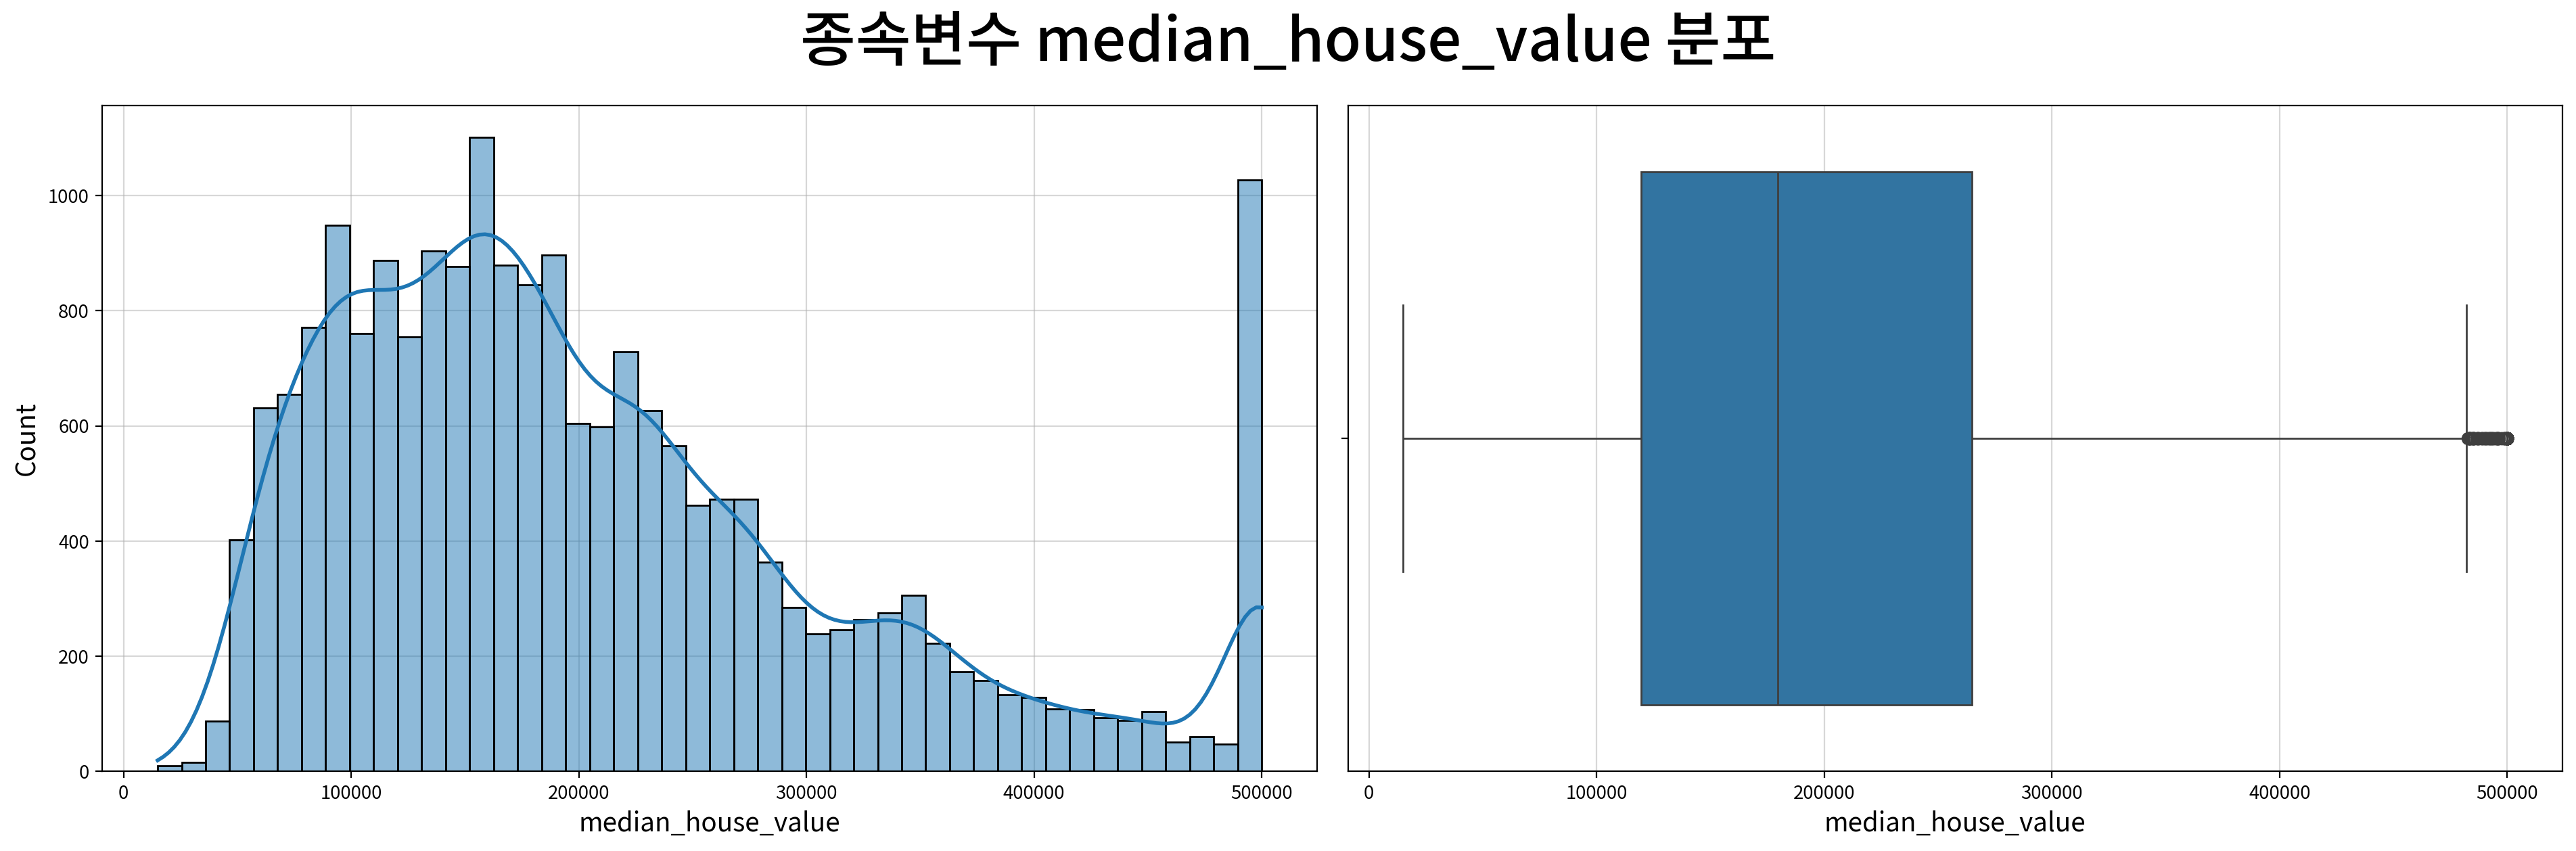

,median_house_value
count,20433.000
mean,206864.413
std,115435.667
min,14999.000
25%,119500.000
50%,179700.000
75%,264700.000
max,500001.000
rel_diff,0.151
rdiff_flag,diff


In [8]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

#### 인사이트

| 점검 항목 | `median_house_value` 관찰값 |
|---|---|
| 분포 모양 | 왜도 +0.978 (우편향), 첨도 0.328 (다소 뾰족함) |
| 봉우리 수 | 단봉 (중앙값 179,700\$ / 평균 206,864\$ 로 평균이 위로 끌림) |
| 이상치 | 상단 1,064건(5.2%) / 하단 0건 |
| 이산점(군집) | 500,001\$에 958건(4.7%) 집중. 최댓값 한 점에 쌓인 인위적 군집 |

- 상한 절단(censoring): 500,001\$는 실제 가격이 아니라 조사 상한에서 잘린 값이다. 우편향(+0.978)의 상당 부분이 이 절단에서 나온다.
  - 상단 이상치 1,064건 중 958건(90%)이 이 한 값이므로, IQR 이상치로 보고 제거하면 고가 구간이 통째로 사라진다.
- 조치: 로그 변환으로 우편향을 완화하고, 500,001 절단 구간은 제거하는 대신 별도 플래그로 관리한다. 모델 평가 시 해당 구간의 과소예측을 감안한다.


### 2. 연속형 독립변수에 대한 단변량 분석

- 반복문을 통해 모든 연속형 변수에 대해 시각화와 기술 통계량을 일괄 생성한다.

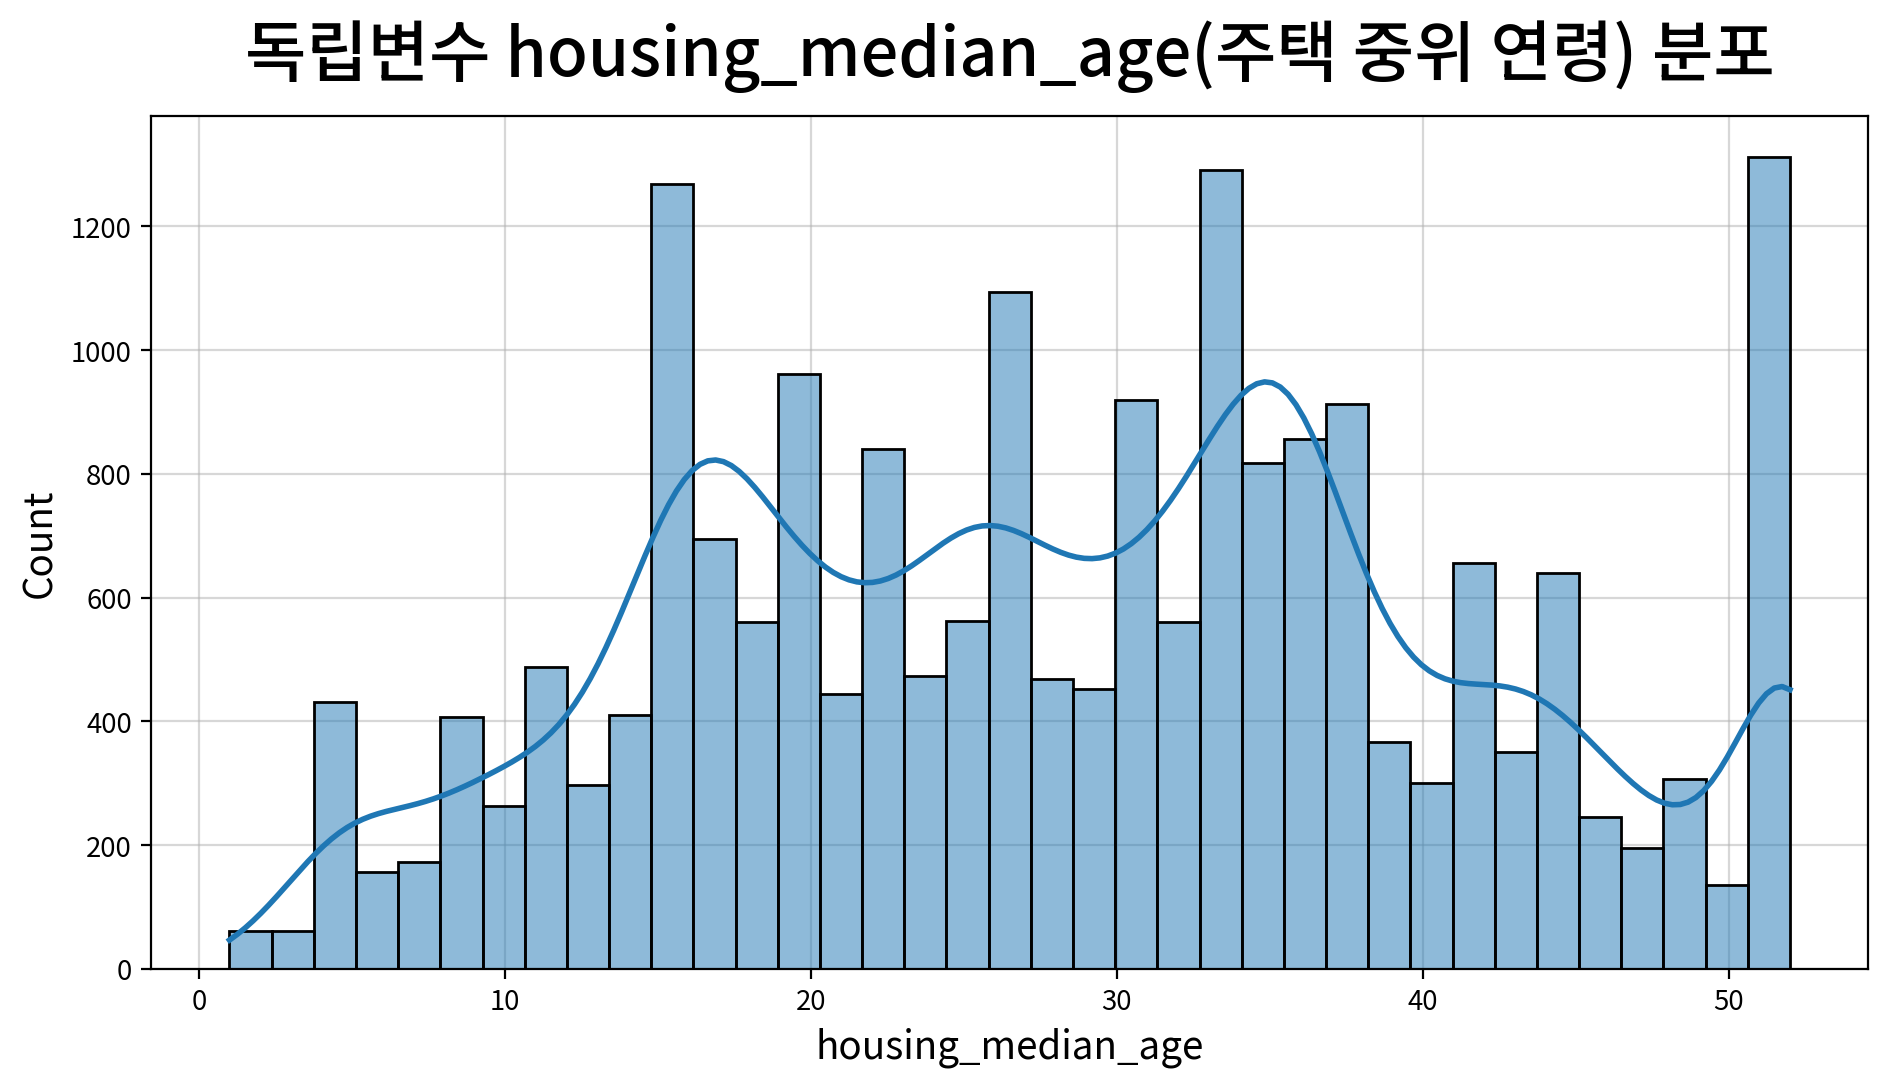

,housing_median_age
count,20433.000
mean,28.633
std,12.592
min,1.000
25%,18.000
50%,29.000
75%,37.000
max,52.000
rel_diff,0.013
rdiff_flag,similar


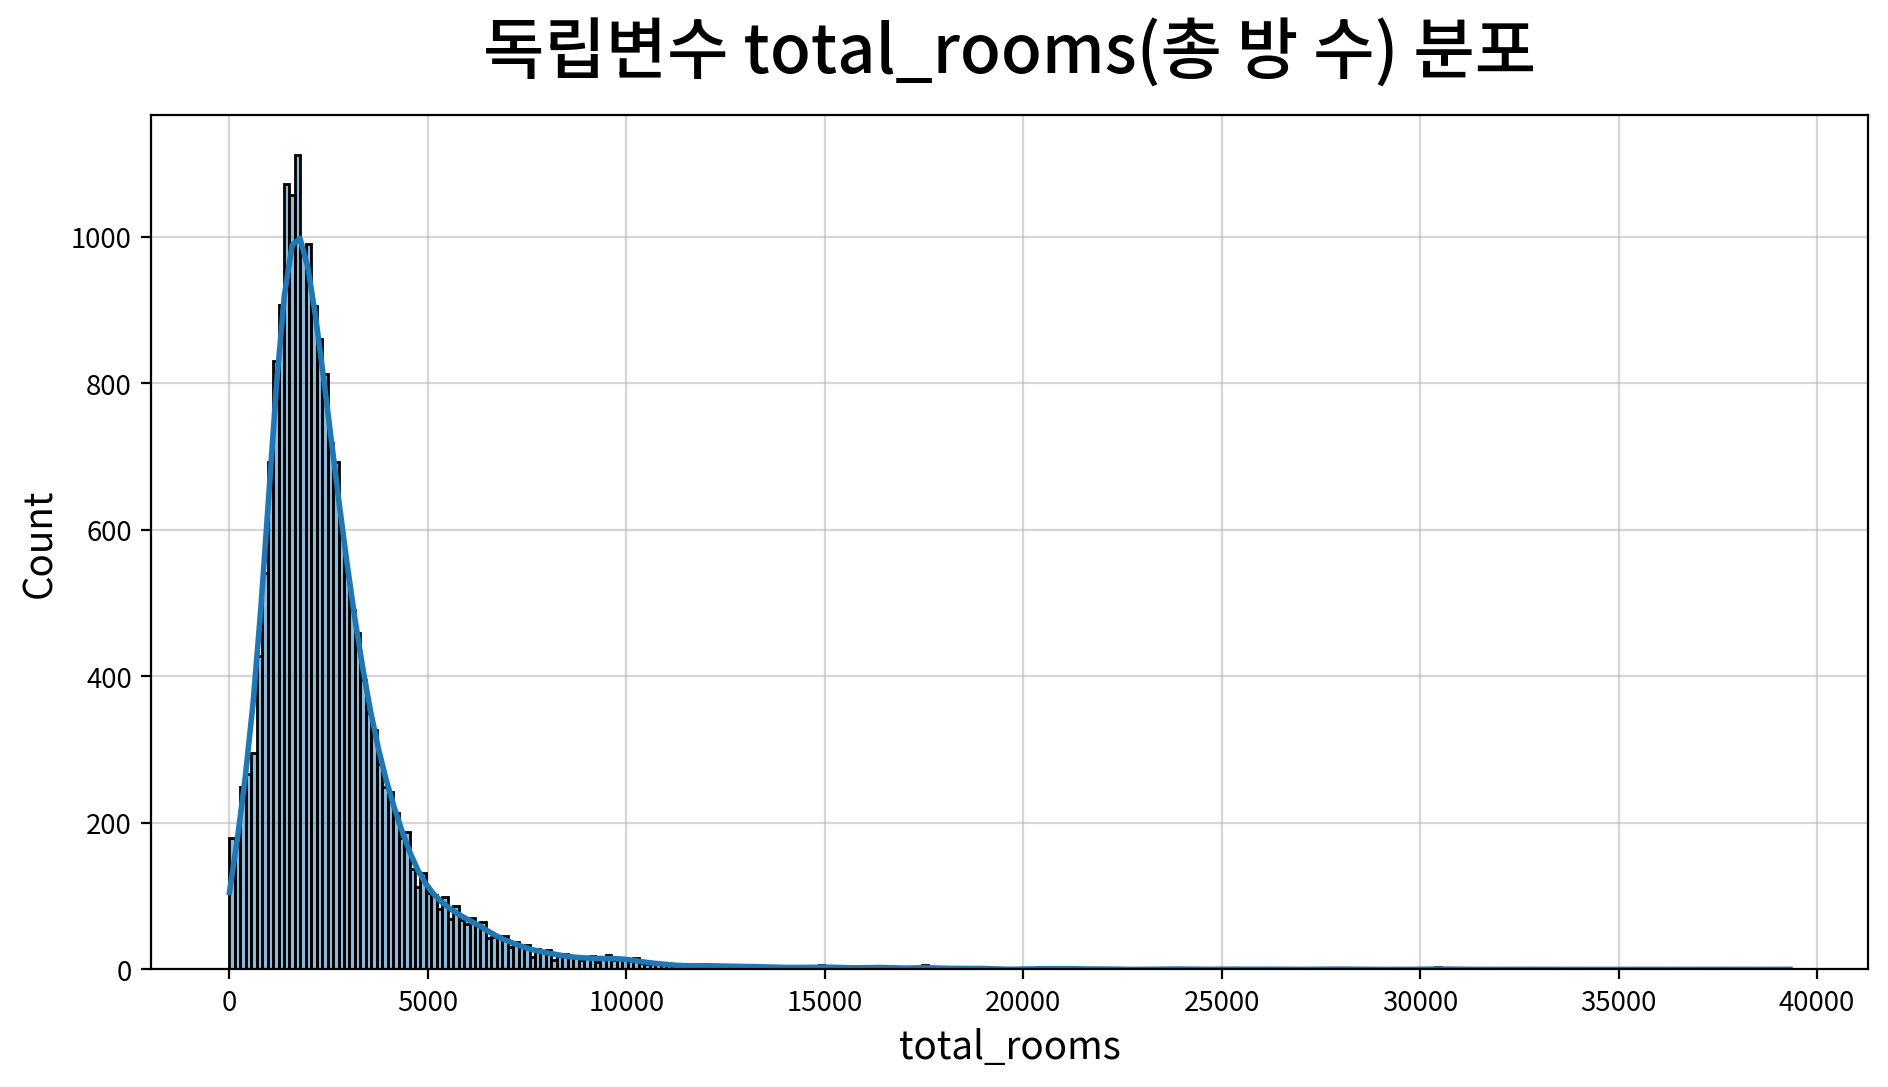

,total_rooms
count,20433.000
mean,2636.504
std,2185.270
min,2.000
25%,1450.000
50%,2127.000
75%,3143.000
max,39320.000
rel_diff,0.240
rdiff_flag,diff


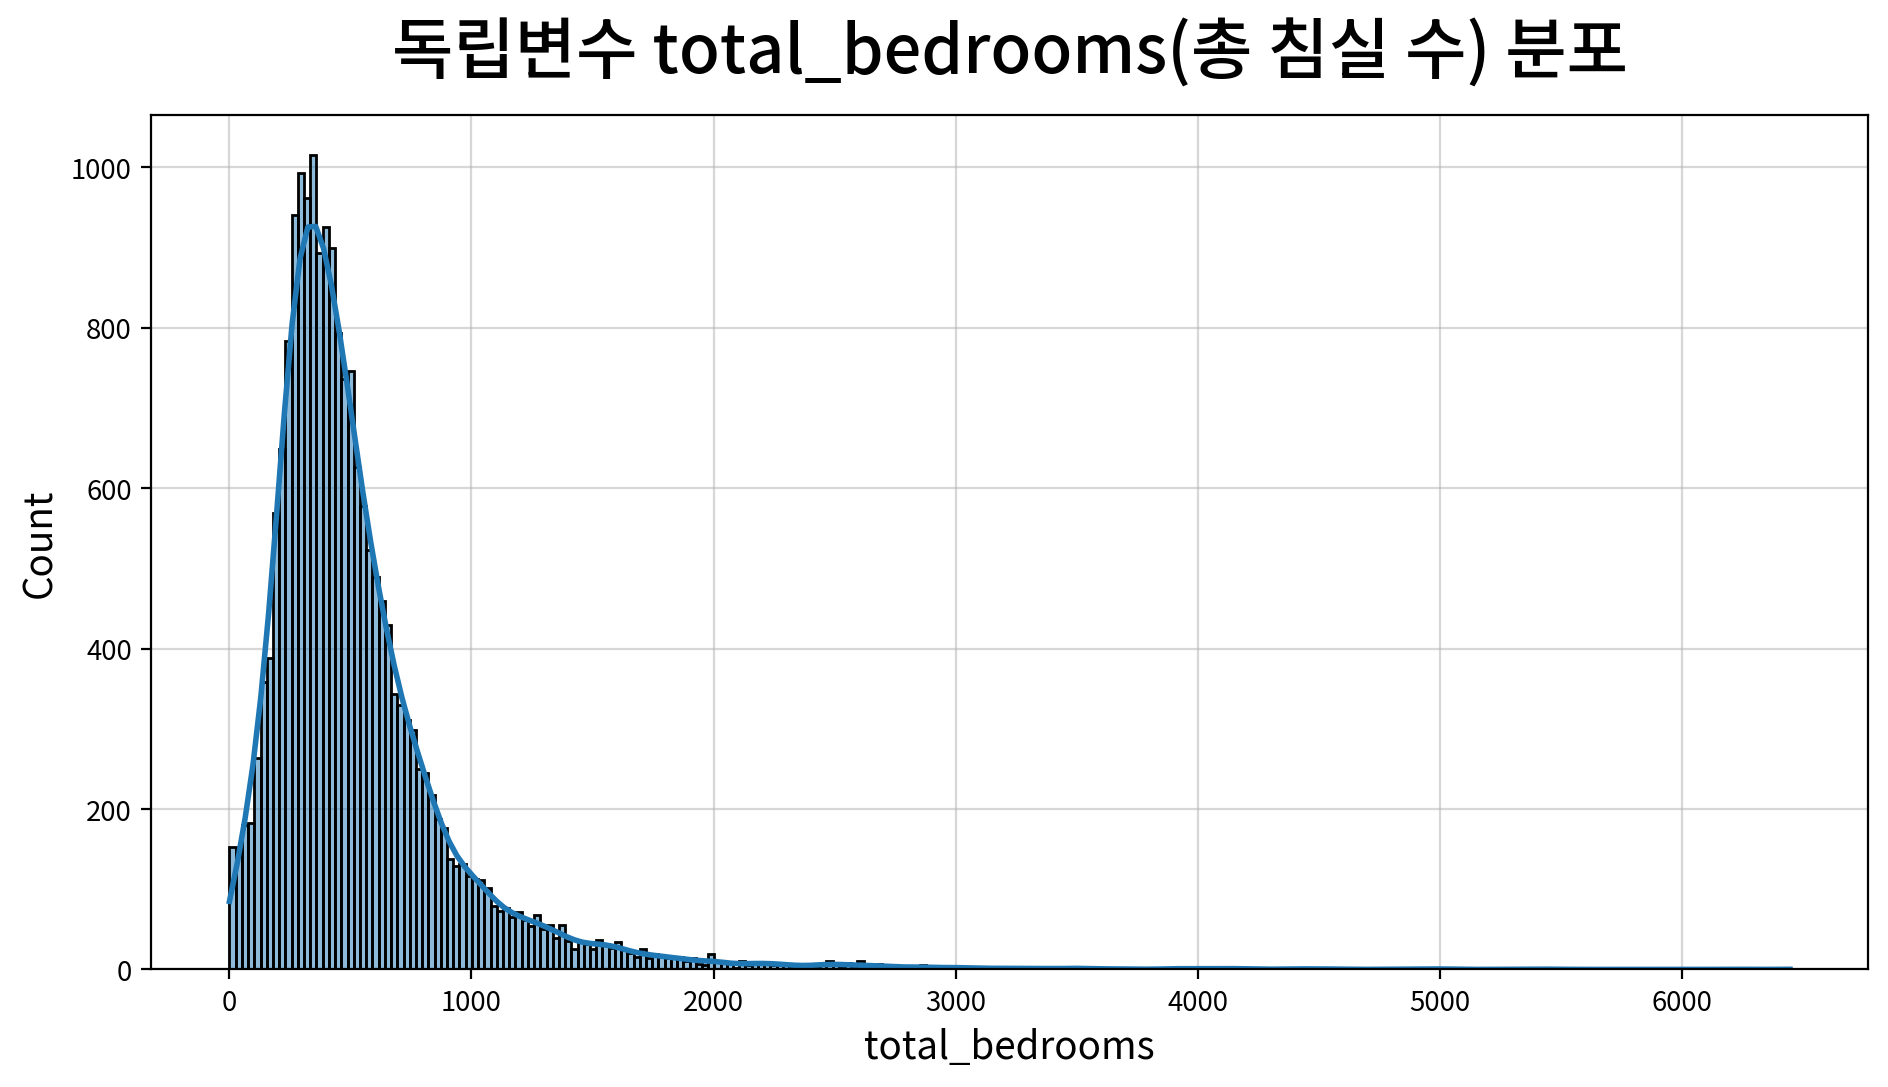

,total_bedrooms
count,20433.000
mean,537.871
std,421.385
min,1.000
25%,296.000
50%,435.000
75%,647.000
max,6445.000
rel_diff,0.236
rdiff_flag,diff


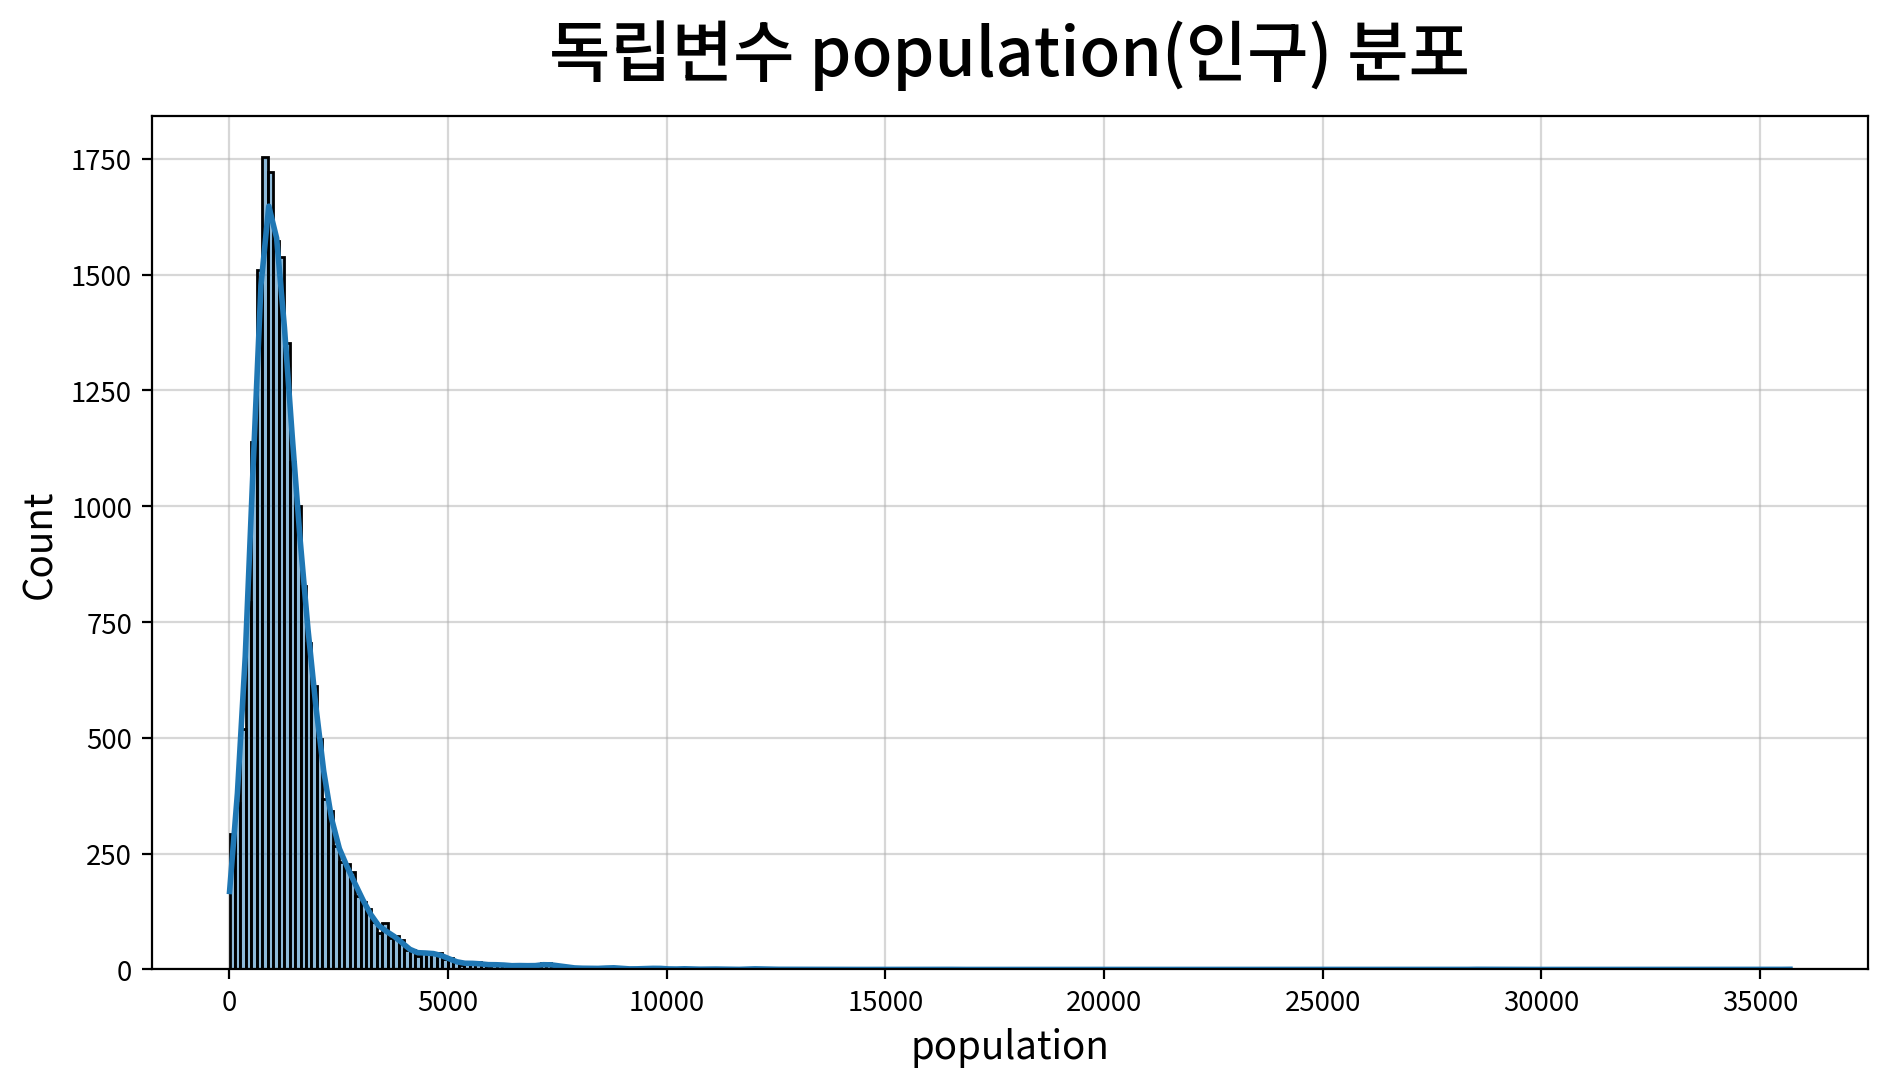

,population
count,20433.000
mean,1424.947
std,1133.208
min,3.000
25%,787.000
50%,1166.000
75%,1722.000
max,35682.000
rel_diff,0.222
rdiff_flag,diff


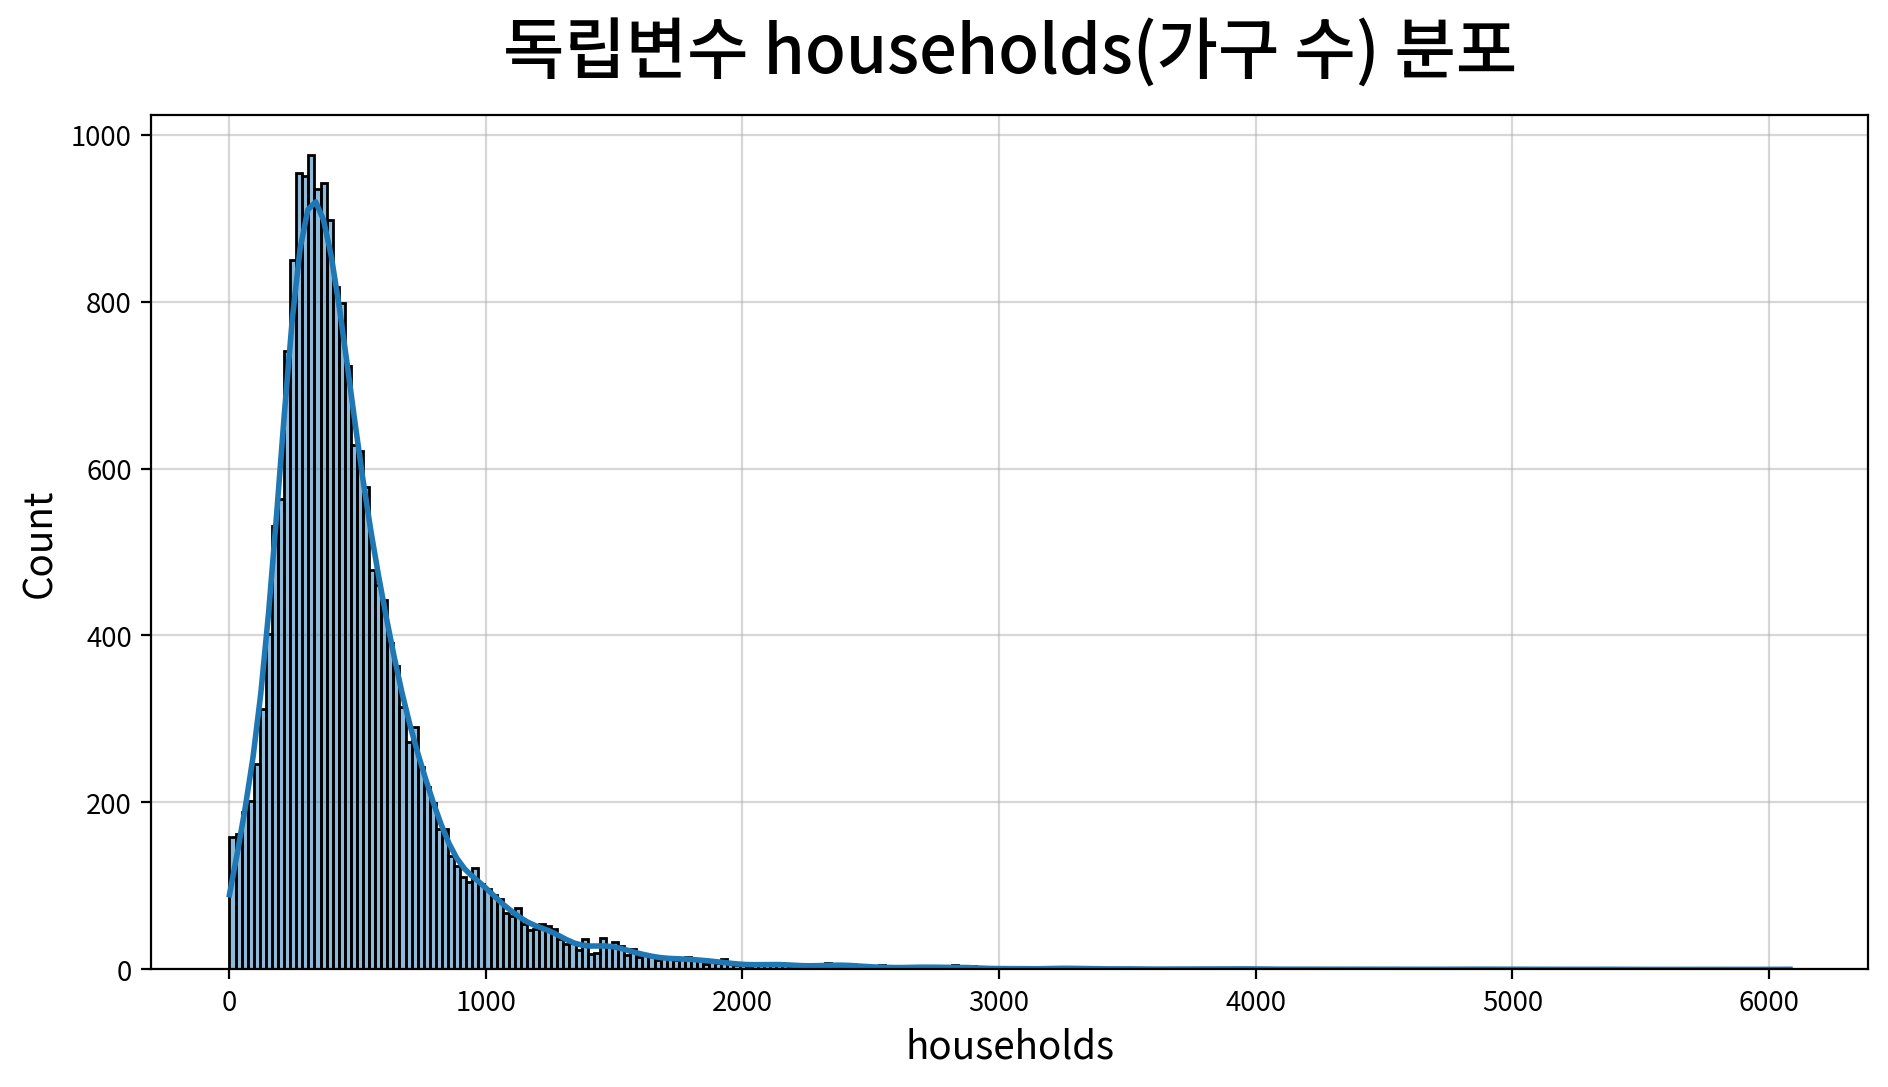

,households
count,20433.000
mean,499.433
std,382.299
min,1.000
25%,280.000
50%,409.000
75%,604.000
max,6082.000
rel_diff,0.221
rdiff_flag,diff


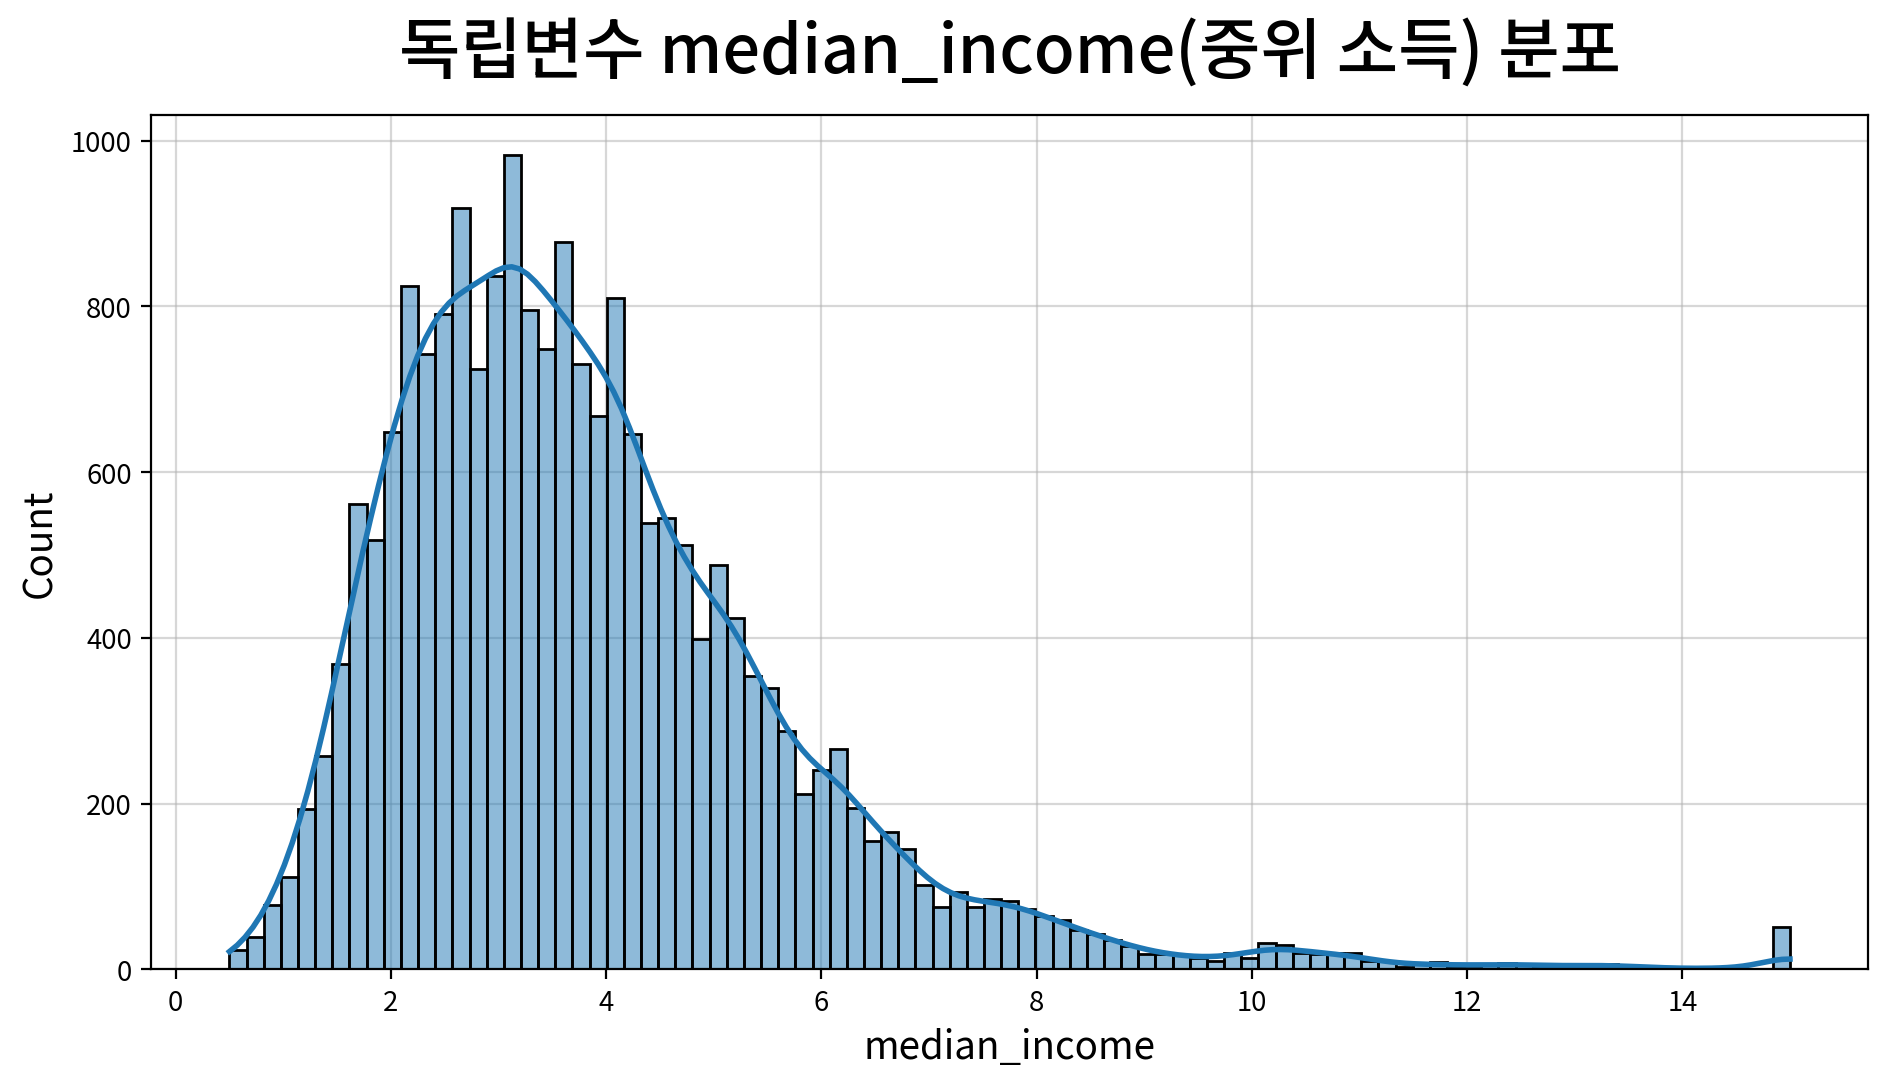

,median_income
count,20433.000
mean,3.871
std,1.899
min,0.500
25%,2.564
50%,3.537
75%,4.744
max,15.000
rel_diff,0.095
rdiff_flag,similar


In [9]:
for f in continuous_cols:
    # 히스토그램 및 박스플롯을 1행 2열 서브플롯으로 구성하는 경우
    #fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
    #            title=f"독립변수 {f}({column_means[f]}) 분포")
    #my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    #my_plot.boxplot(data=df, x=f, ax=ax[1])
    #my_plot.show()

    # 히스토그램만 그리는 경우
    my_plot.histplot(data=df, x=f, kde=True, width=960, height=560,
                    title=f"독립변수 {f}({column_means[f]}) 분포")

    display(num_desc[num_desc.index == f].T)

#### 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 이산점(군집) | 판단·조치 |
|---|---|---|---|---|---|
| `housing_median_age` | 거의 대칭 (+0.062) | 넓게 퍼진 평탄형 (첨도 -0.801) | 없음 (0건) | 52년에 1,265건(6.2%) 집중 | 변환 불필요. 52 = 상한 절단 주의 |
| `total_rooms` | 강한 우편향 (+4.16) | 단봉 + 긴 우측 꼬리 | 많음 (6.3%) | 없음 (연속) | 로그 변환(log) |
| `total_bedrooms` | 강한 우편향 (+3.46) | 단봉 + 긴 우측 꼬리 | 많음 (6.2%) | 없음 (연속) | 로그 변환(log) |
| `population` | 가장 강한 우편향 (+4.96) | 단봉 + 극단 꼬리 (첨도 74.1) | 많음 (5.8%) | 없음 (연속) | 로그 변환(log) |
| `households` | 강한 우편향 (+3.41) | 단봉 + 긴 우측 꼬리 | 많음 (5.9%) | 없음 (연속) | 로그 변환(log) |
| `median_income` | 중간 우편향 (+1.65) | 단봉 (중앙값 3.54) | 다소 있음 (3.3%) | 15.0에 50건 집중 | 로그 변환 + 15.0 상한 절단 인지 |

- `total_rooms`·`total_bedrooms`·`population`·`households` 4종이 모두 같은 모양(강한 우편향에 6% 내외의 상단 이상치)이다. 넷 다 구역(block)에 몇 개가 있는지를 세는 총량 변수라서, 인구가 많은 구역 하나가 4개 변수를 동시에 키운다. 다변량 단계에서 공선성을 확인해야 한다.
- 총량 변수의 이상치는 오류값이 아니다. `population` 최댓값 35,682명은 실제로 인구가 많은 구역일 뿐 물리적으로 불가능한 값이 아니다. 제거 대상이 아니라 로그 변환 대상이다.
- `housing_median_age`의 52년 집중(6.2%)은 종속변수의 500,001\$와 같은 상한 절단이다. 53년 이상은 모두 52로 기록되었다.
- `median_income`의 15.0 집중(50건)도 상한 절단(단위 = 만 달러)이다. 건수가 적어 영향은 제한적이다.


### 3. 범주형 독립변수에 대한 단변량 분석

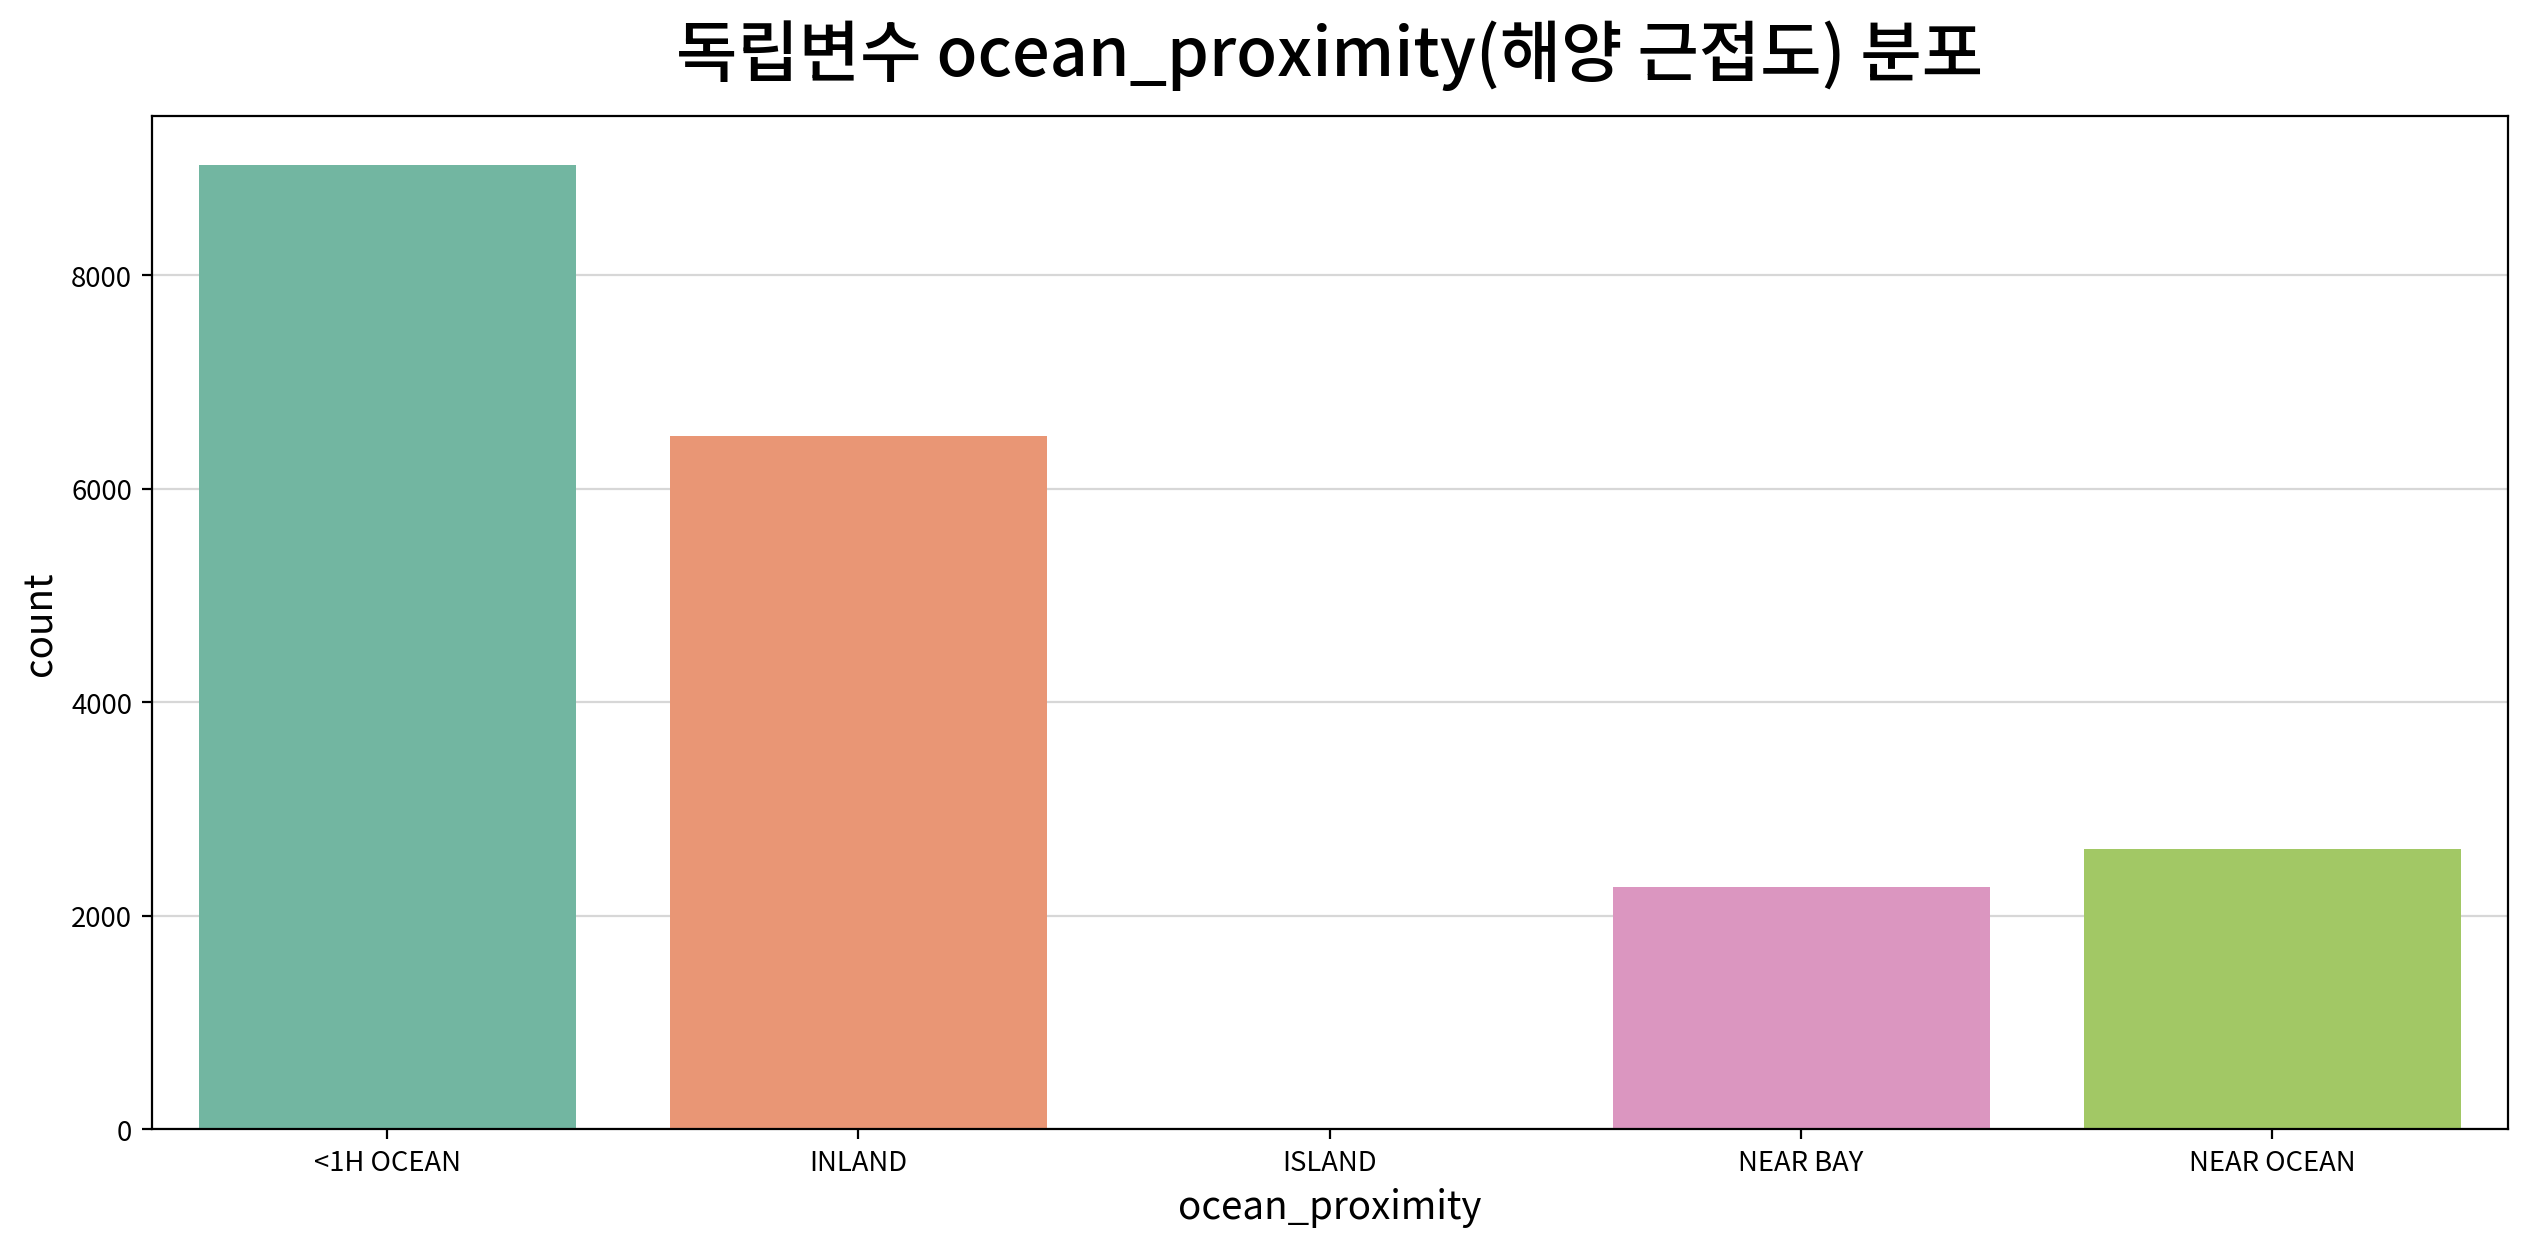

,count,unique,top,freq
ocean_proximity,20433,5,<1H OCEAN,9034


,빈도,비율
ocean_proximity,,
<1H OCEAN,9034,0.442
INLAND,6496,0.318
NEAR OCEAN,2628,0.129
NEAR BAY,2270,0.111
ISLAND,5,0.000


In [10]:
for n in nominal_cols:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", 
                      title=f"독립변수 {n}({column_means[n]}) 분포")

    # 범주형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `ocean_proximity` | 5 | \<1H OCEAN 9,034 (44.2%) | ISLAND 5 (0.02%) | 극심한 불균형 | 3집단 이상이므로 ANOVA 대상 |

- 범주 구성: `<1H OCEAN` 9,034(44.2%) / `INLAND` 6,496(31.8%) / `NEAR OCEAN` 2,628(12.9%) / `NEAR BAY` 2,270(11.1%) / `ISLAND` 5(0.02%)
- `ISLAND` 5건이 문제다. 표본이 5개뿐이라 집단 평균의 신뢰구간이 지나치게 넓고, 사후검정에서 이 범주가 낀 쌍은 평균 차이가 크게 나와도 유의하지 않게 나올 수 있다(검정력 부족).
  - 조치: 해석에서 제외하거나 `NEAR OCEAN` 등 인접 범주와 병합한 뒤 재검정한다. 더미 인코딩을 하면 5건짜리 열이 하나 생기므로 병합하는 편이 안전하다.
- 나머지 4개 범주는 상위 2개가 76%를 차지하지만 각 범주가 2,000건 이상이라 검정에는 충분하다.


## #03. 이변량 분석

### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ housing_median_age(주택 중위 연령) → median_house_value

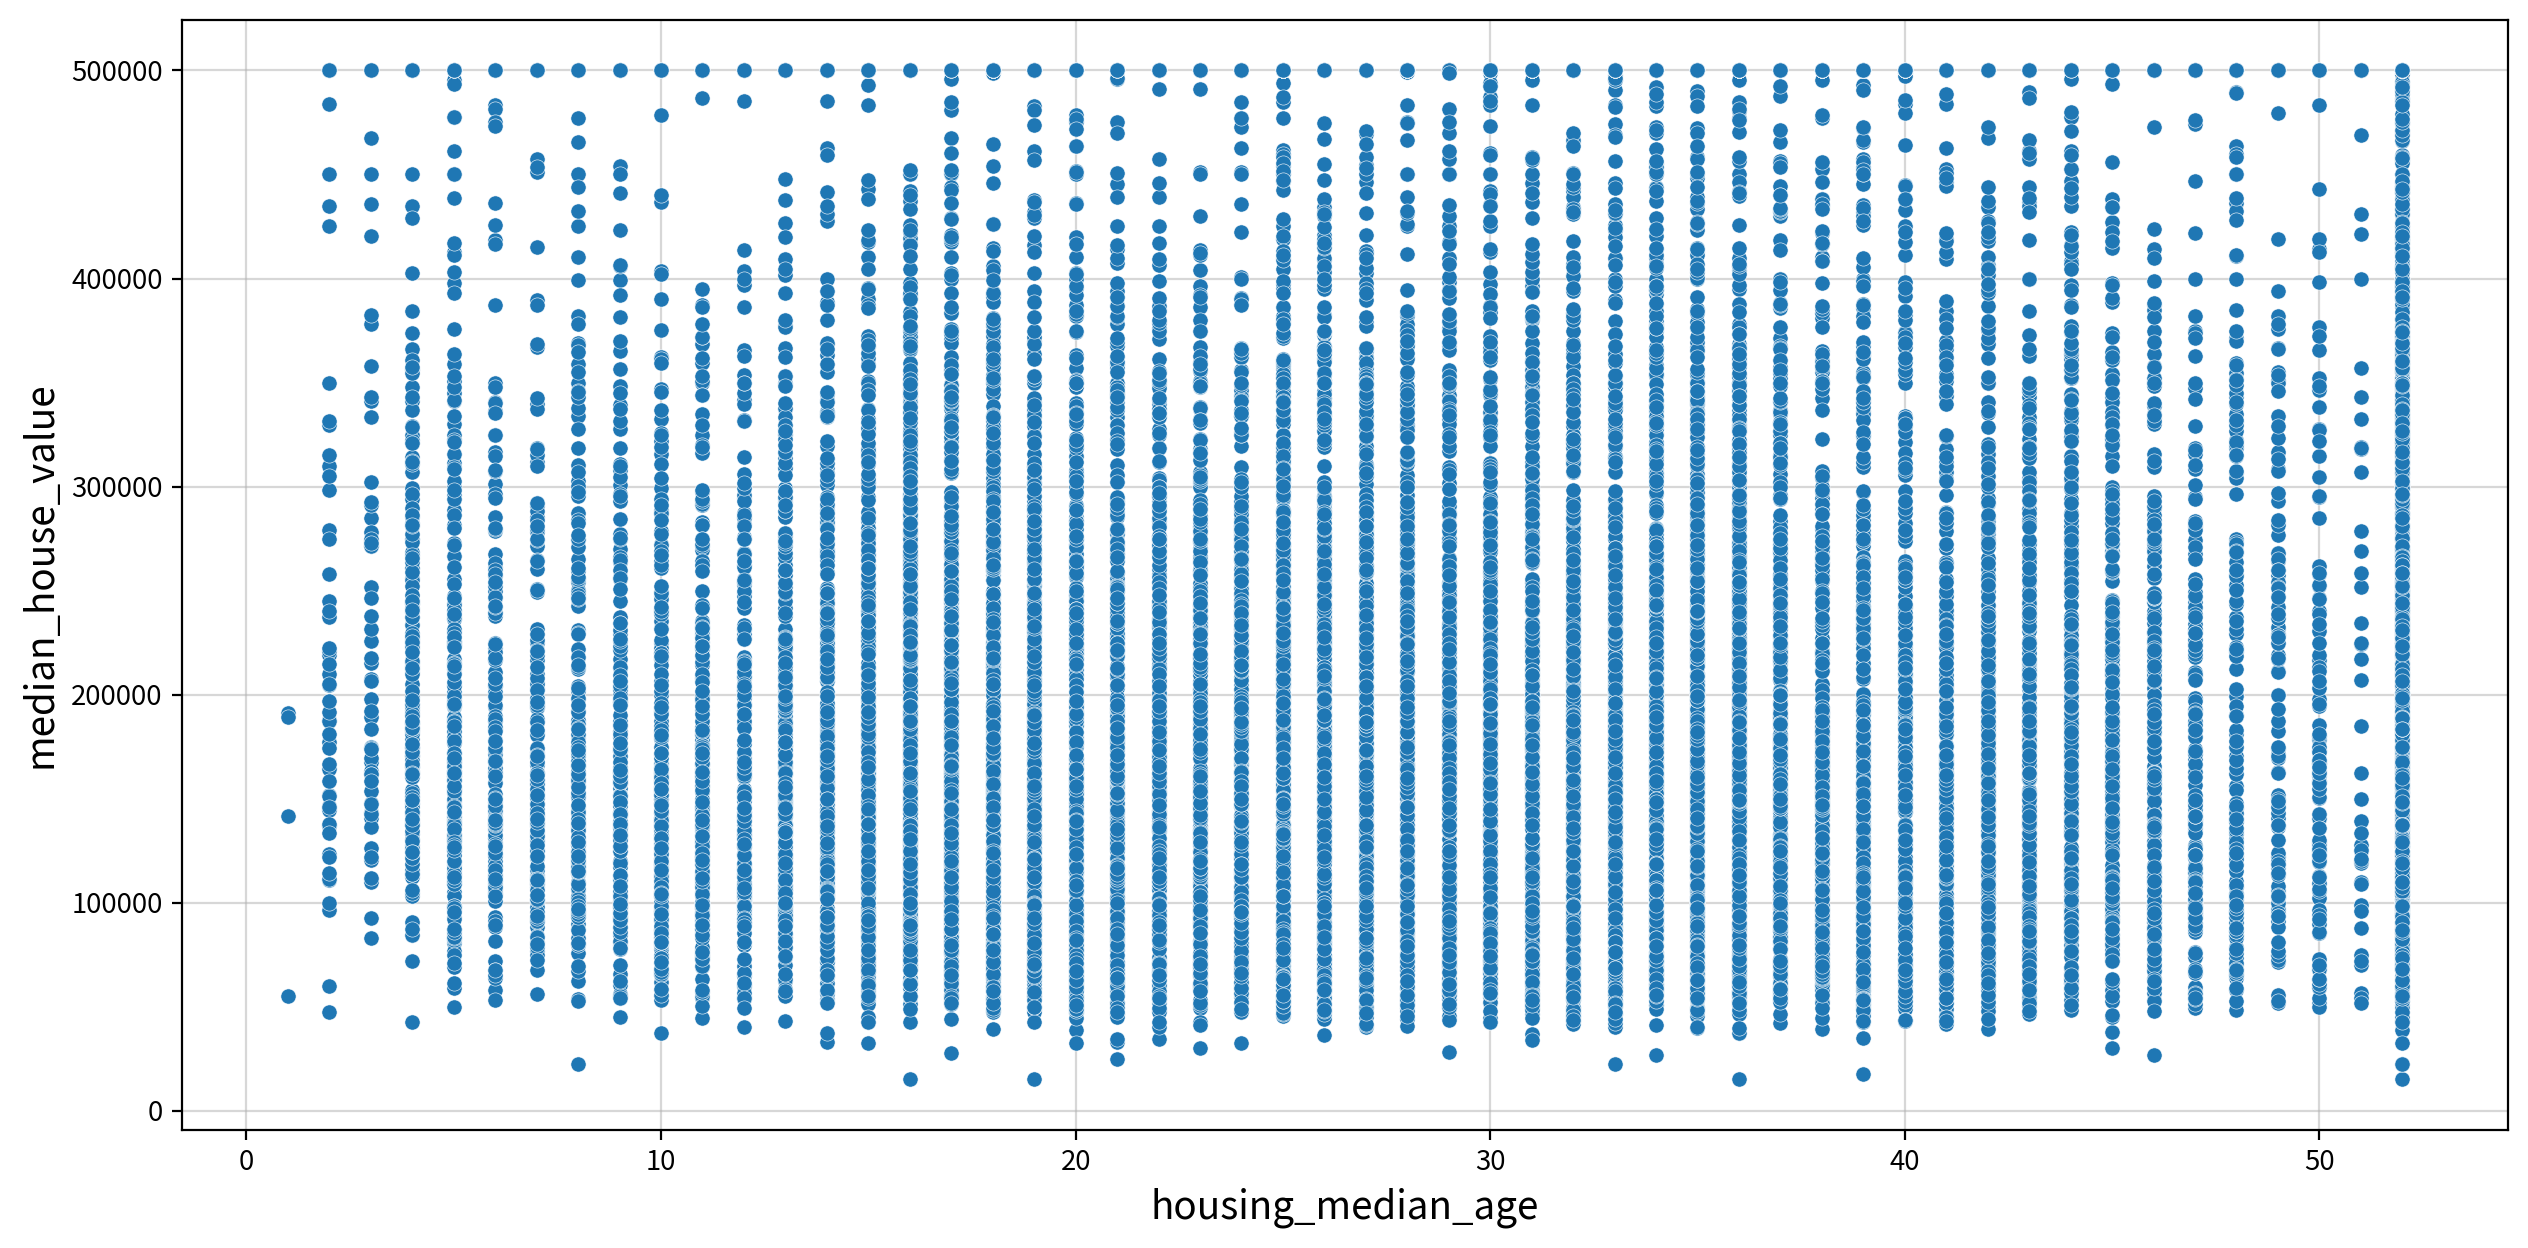

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
housing_median_age,median_house_value,Spearman,0.075,0.000,Weak,True,False,False,False,False,False


#### ▶︎ total_rooms(총 방 수) → median_house_value

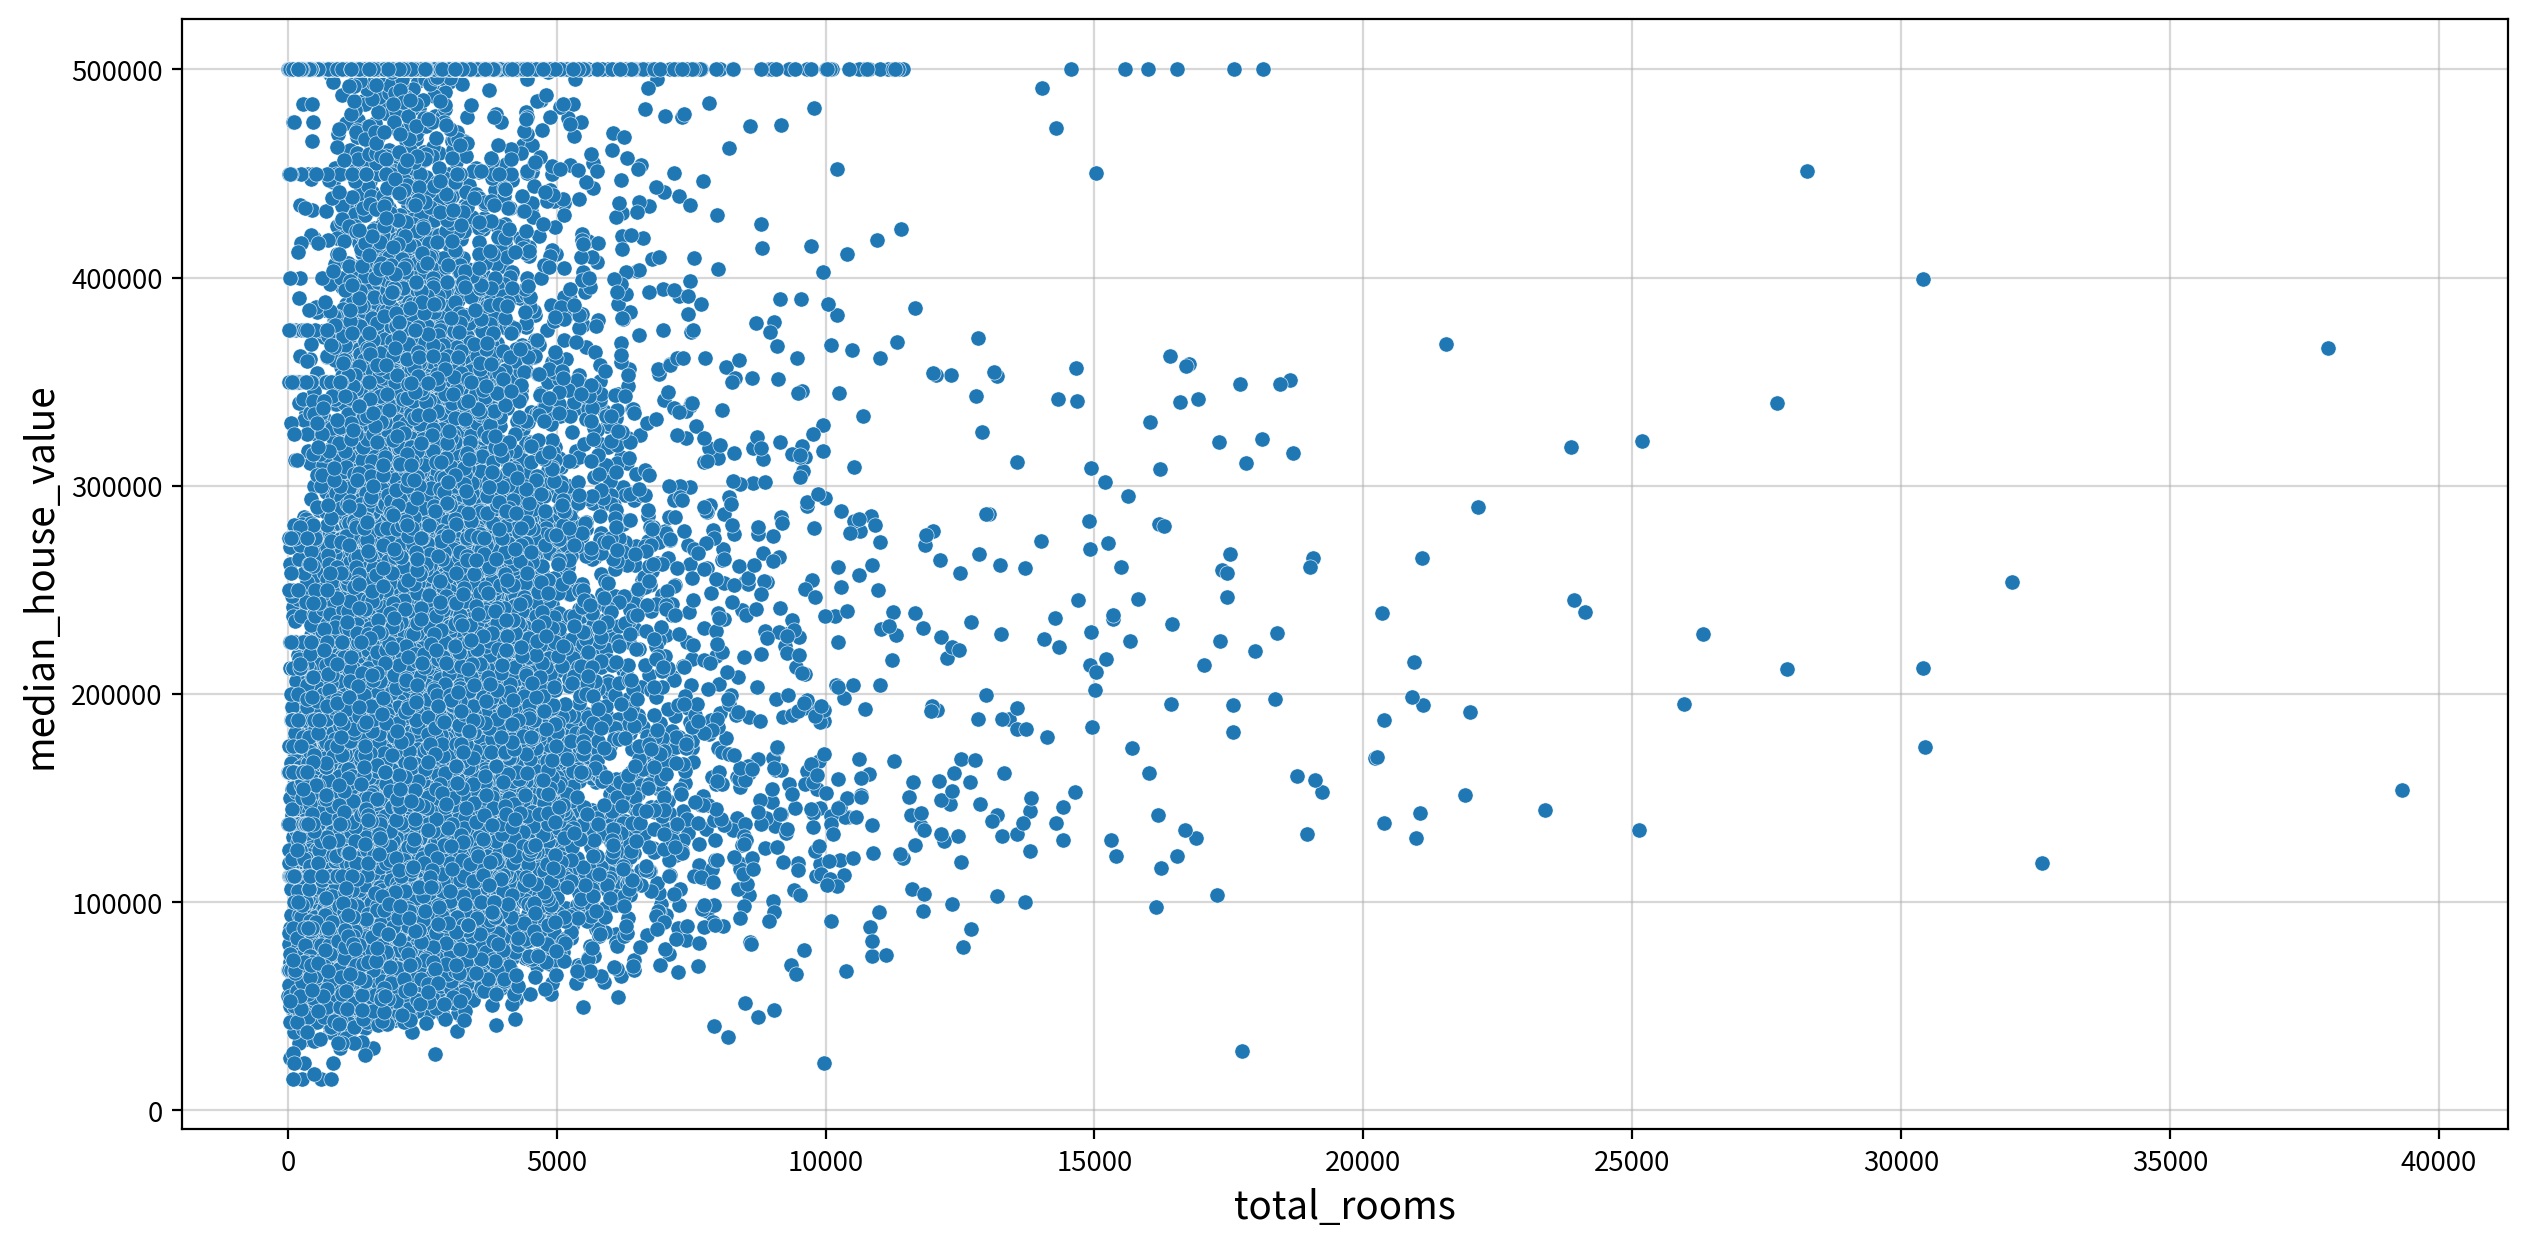

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_rooms,median_house_value,Spearman,0.205,0.000,Weak,True,False,False,False,False,True


#### ▶︎ total_bedrooms(총 침실 수) → median_house_value

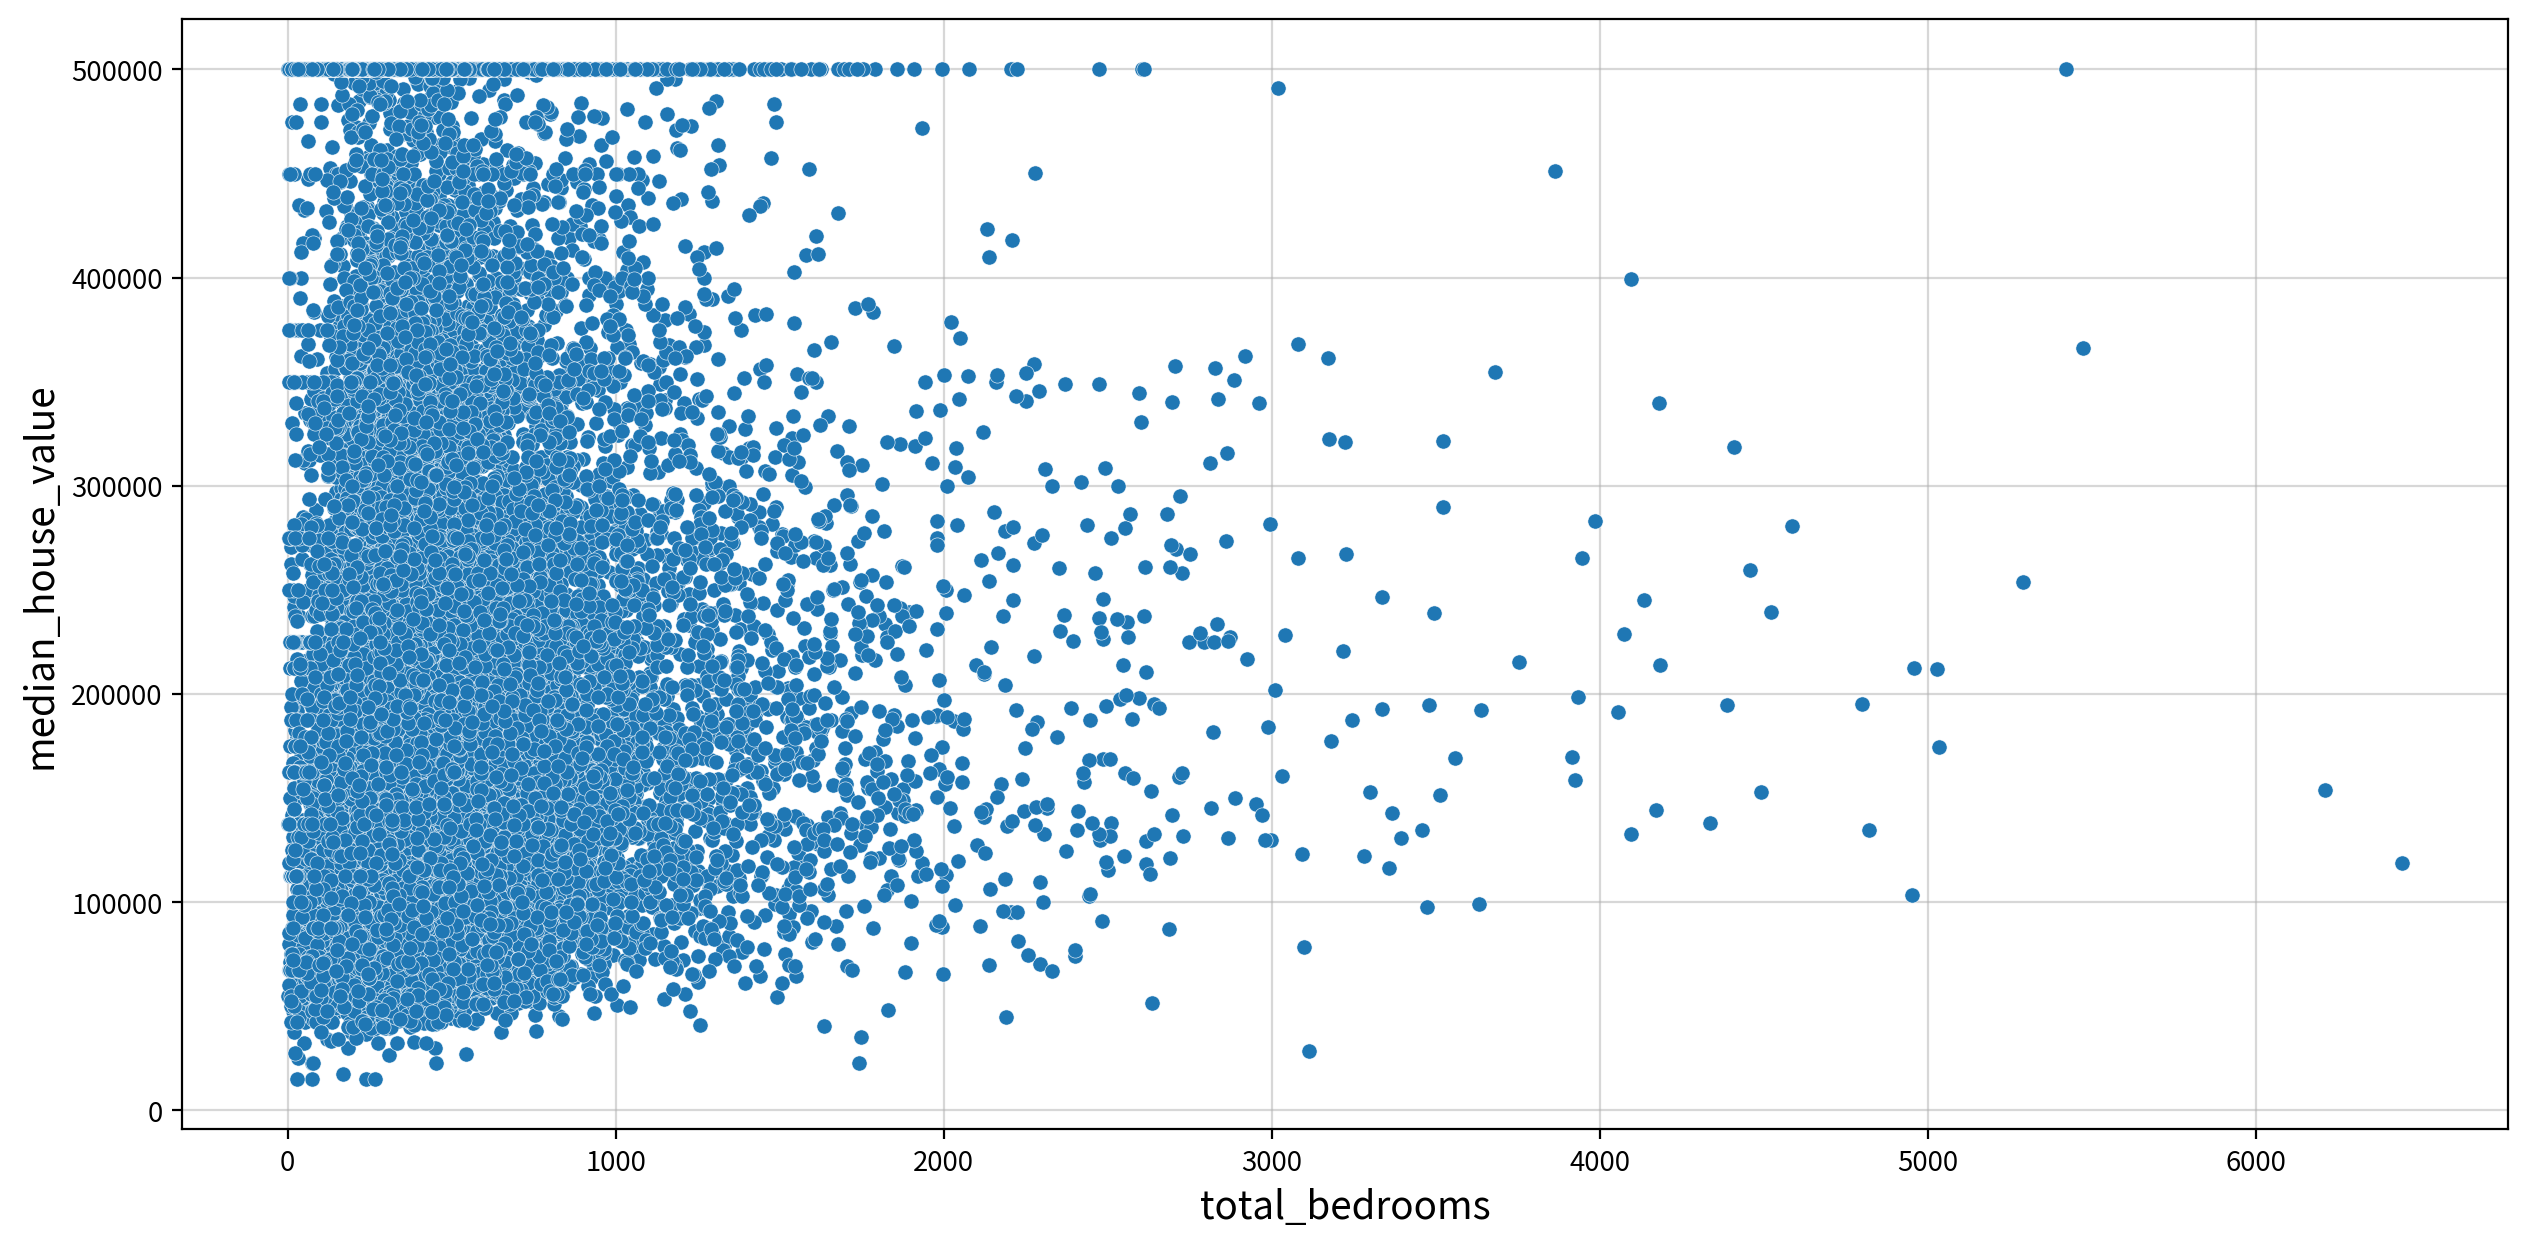

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_bedrooms,median_house_value,Spearman,0.086,0.000,Weak,True,False,False,False,False,True


#### ▶︎ population(인구) → median_house_value

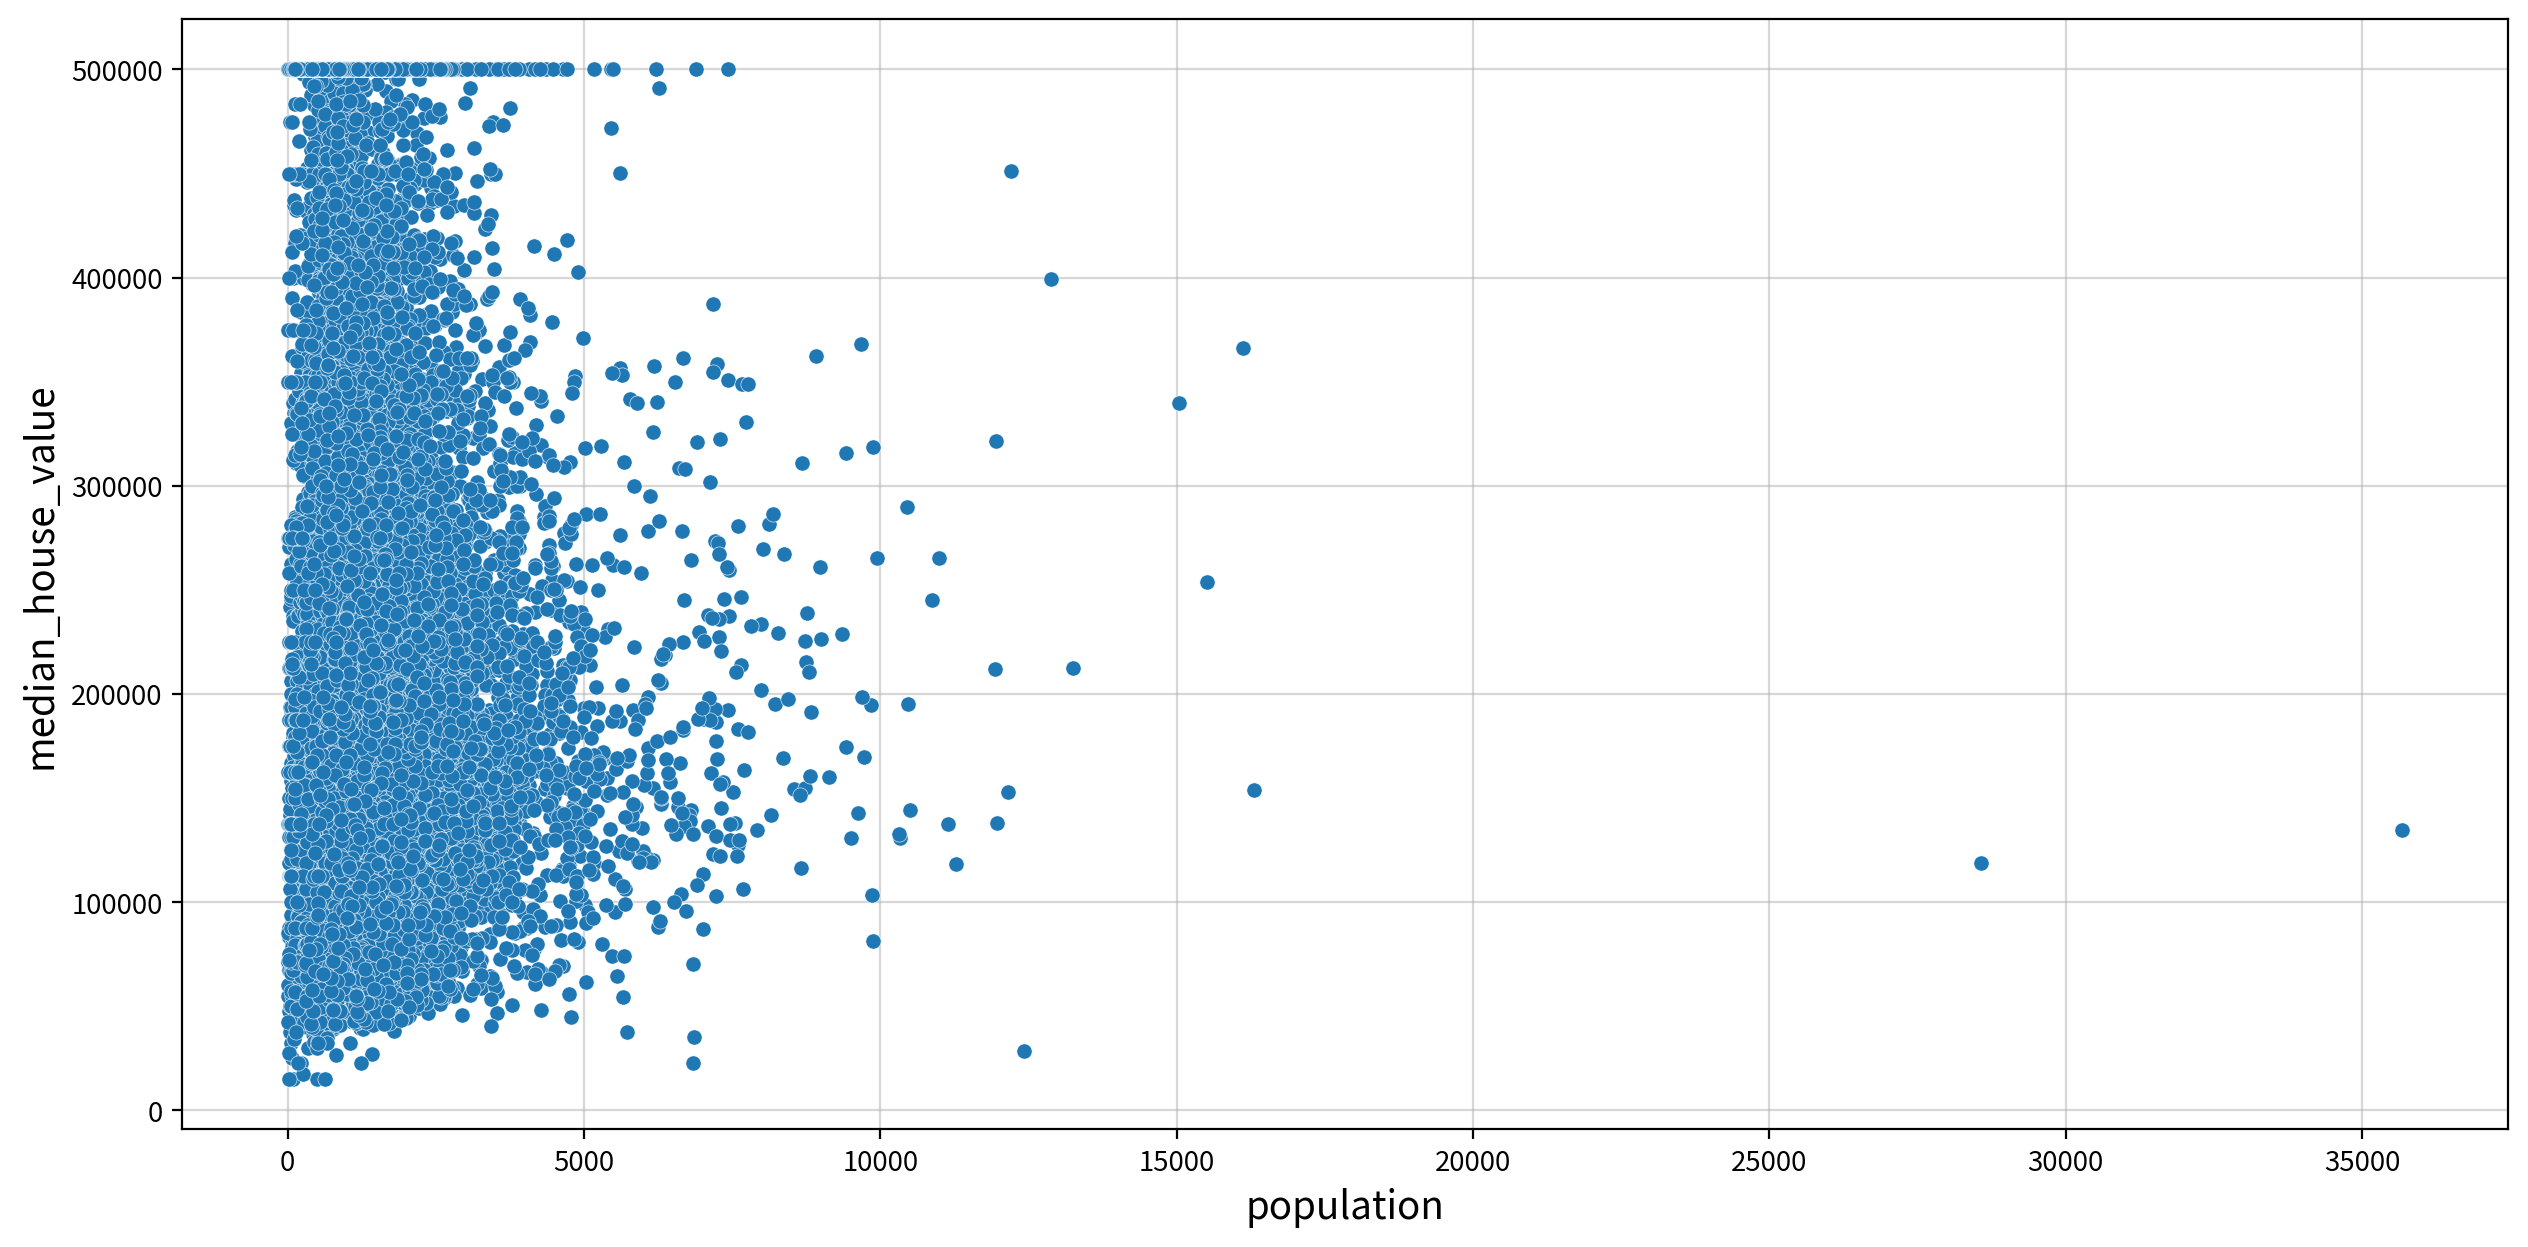

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population,median_house_value,Spearman,0.003,0.681,Weak,False,False,False,True,False,True


#### ▶︎ households(가구 수) → median_house_value

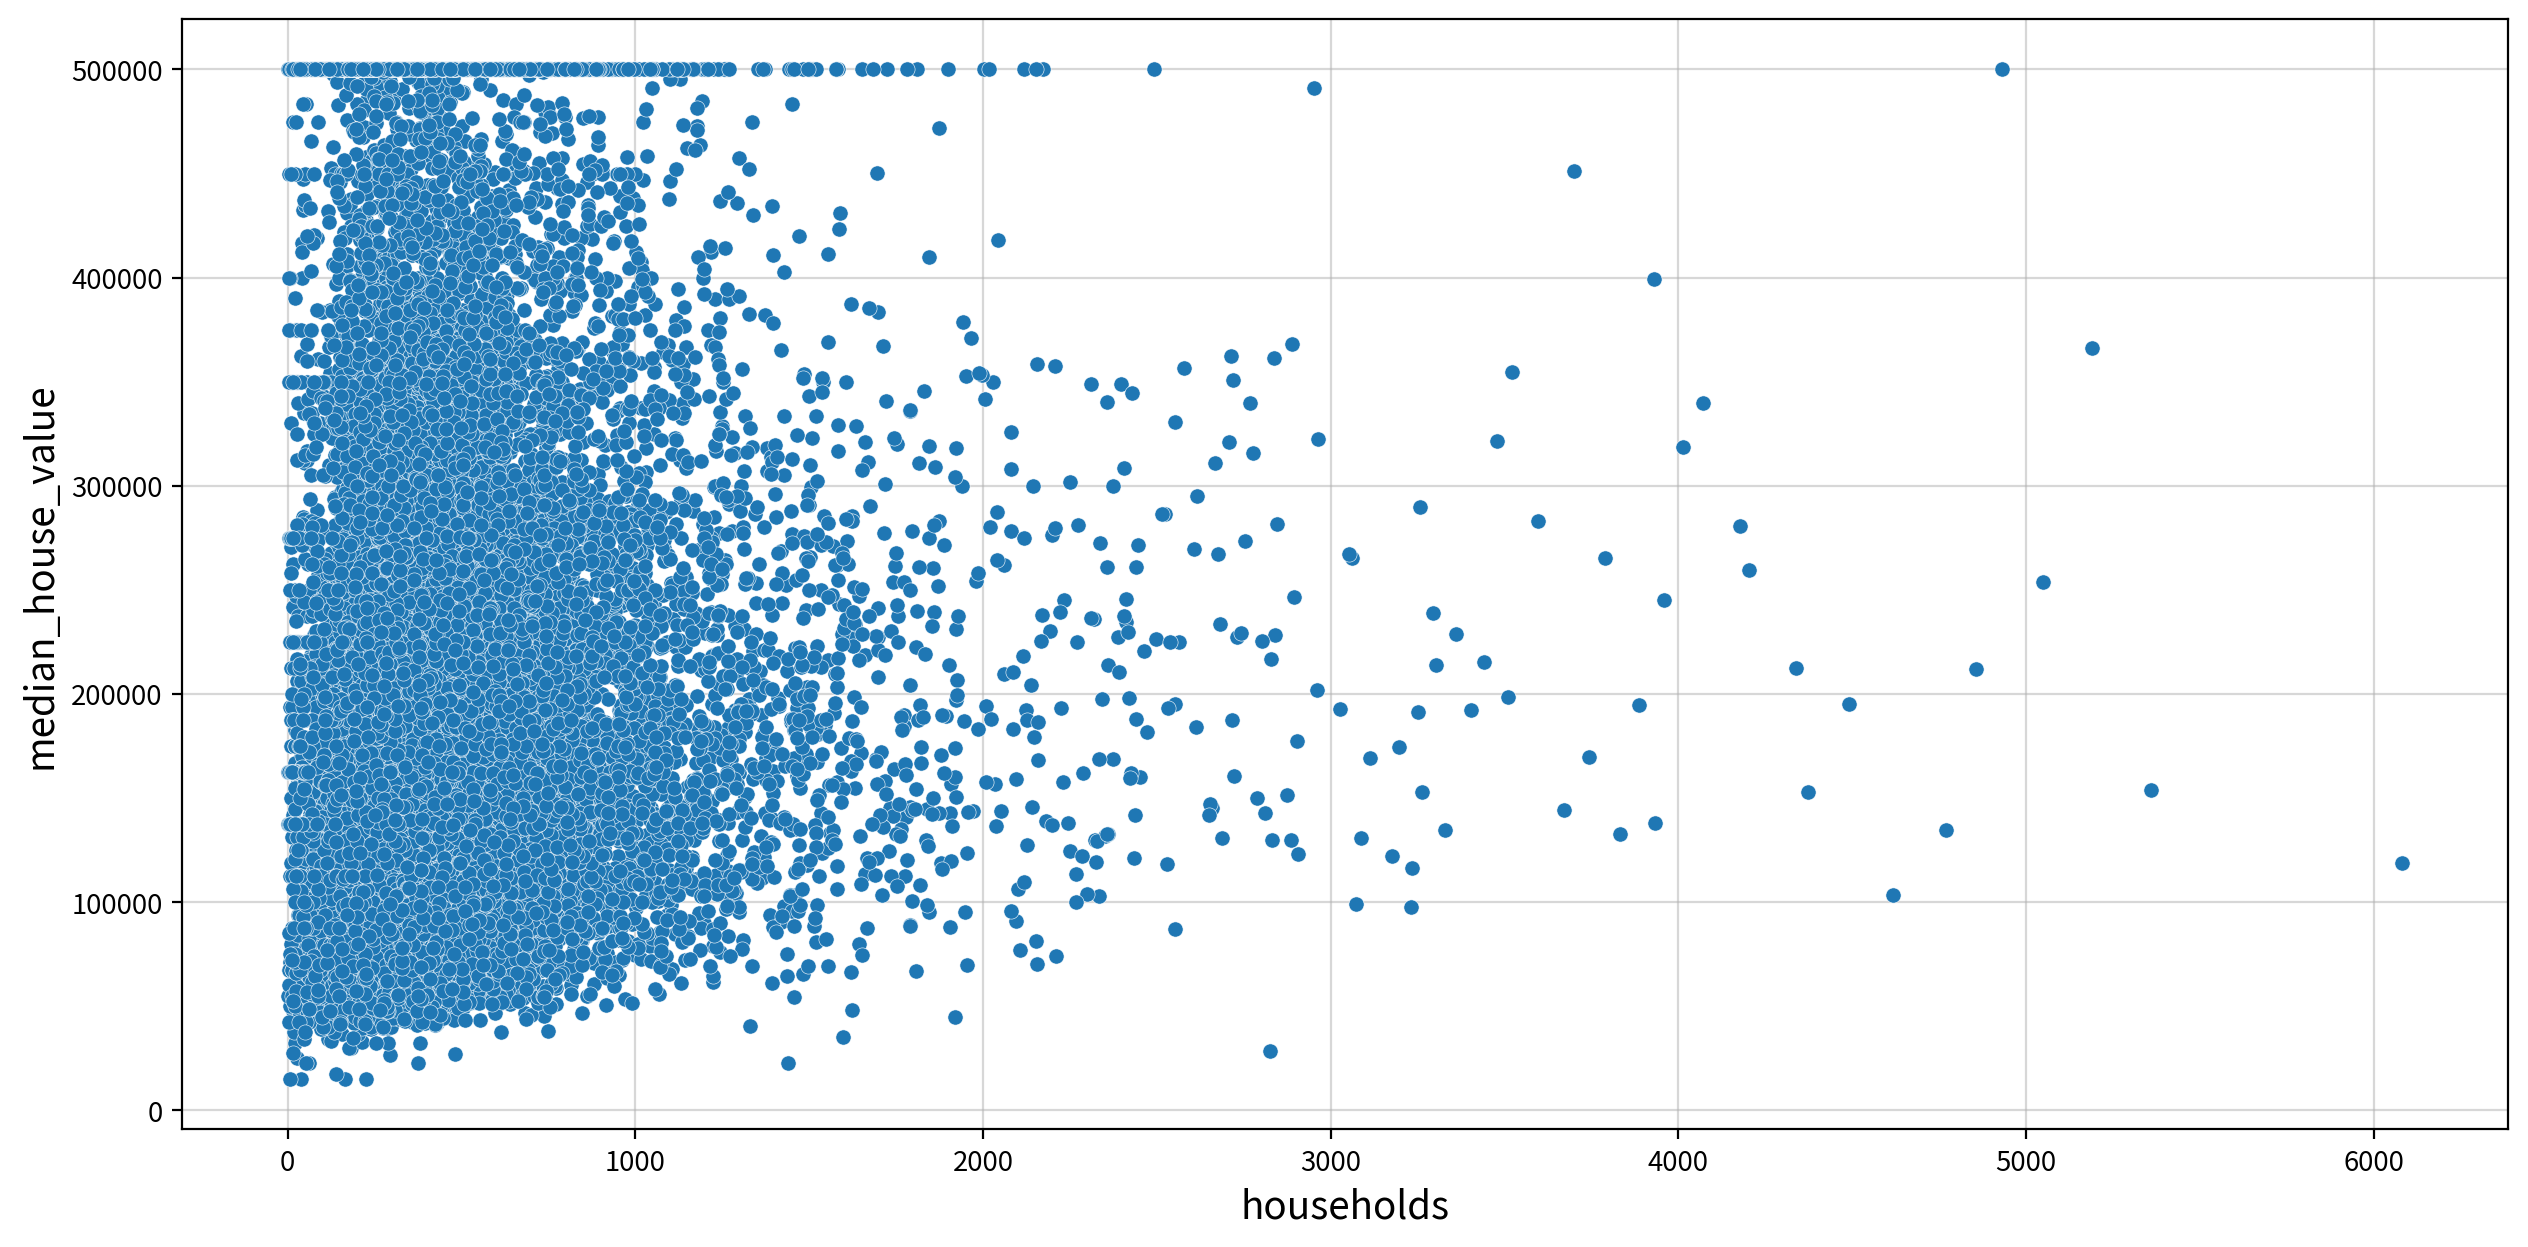

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
households,median_house_value,Spearman,0.112,0.000,Weak,True,False,False,False,False,True


#### ▶︎ median_income(중위 소득) → median_house_value

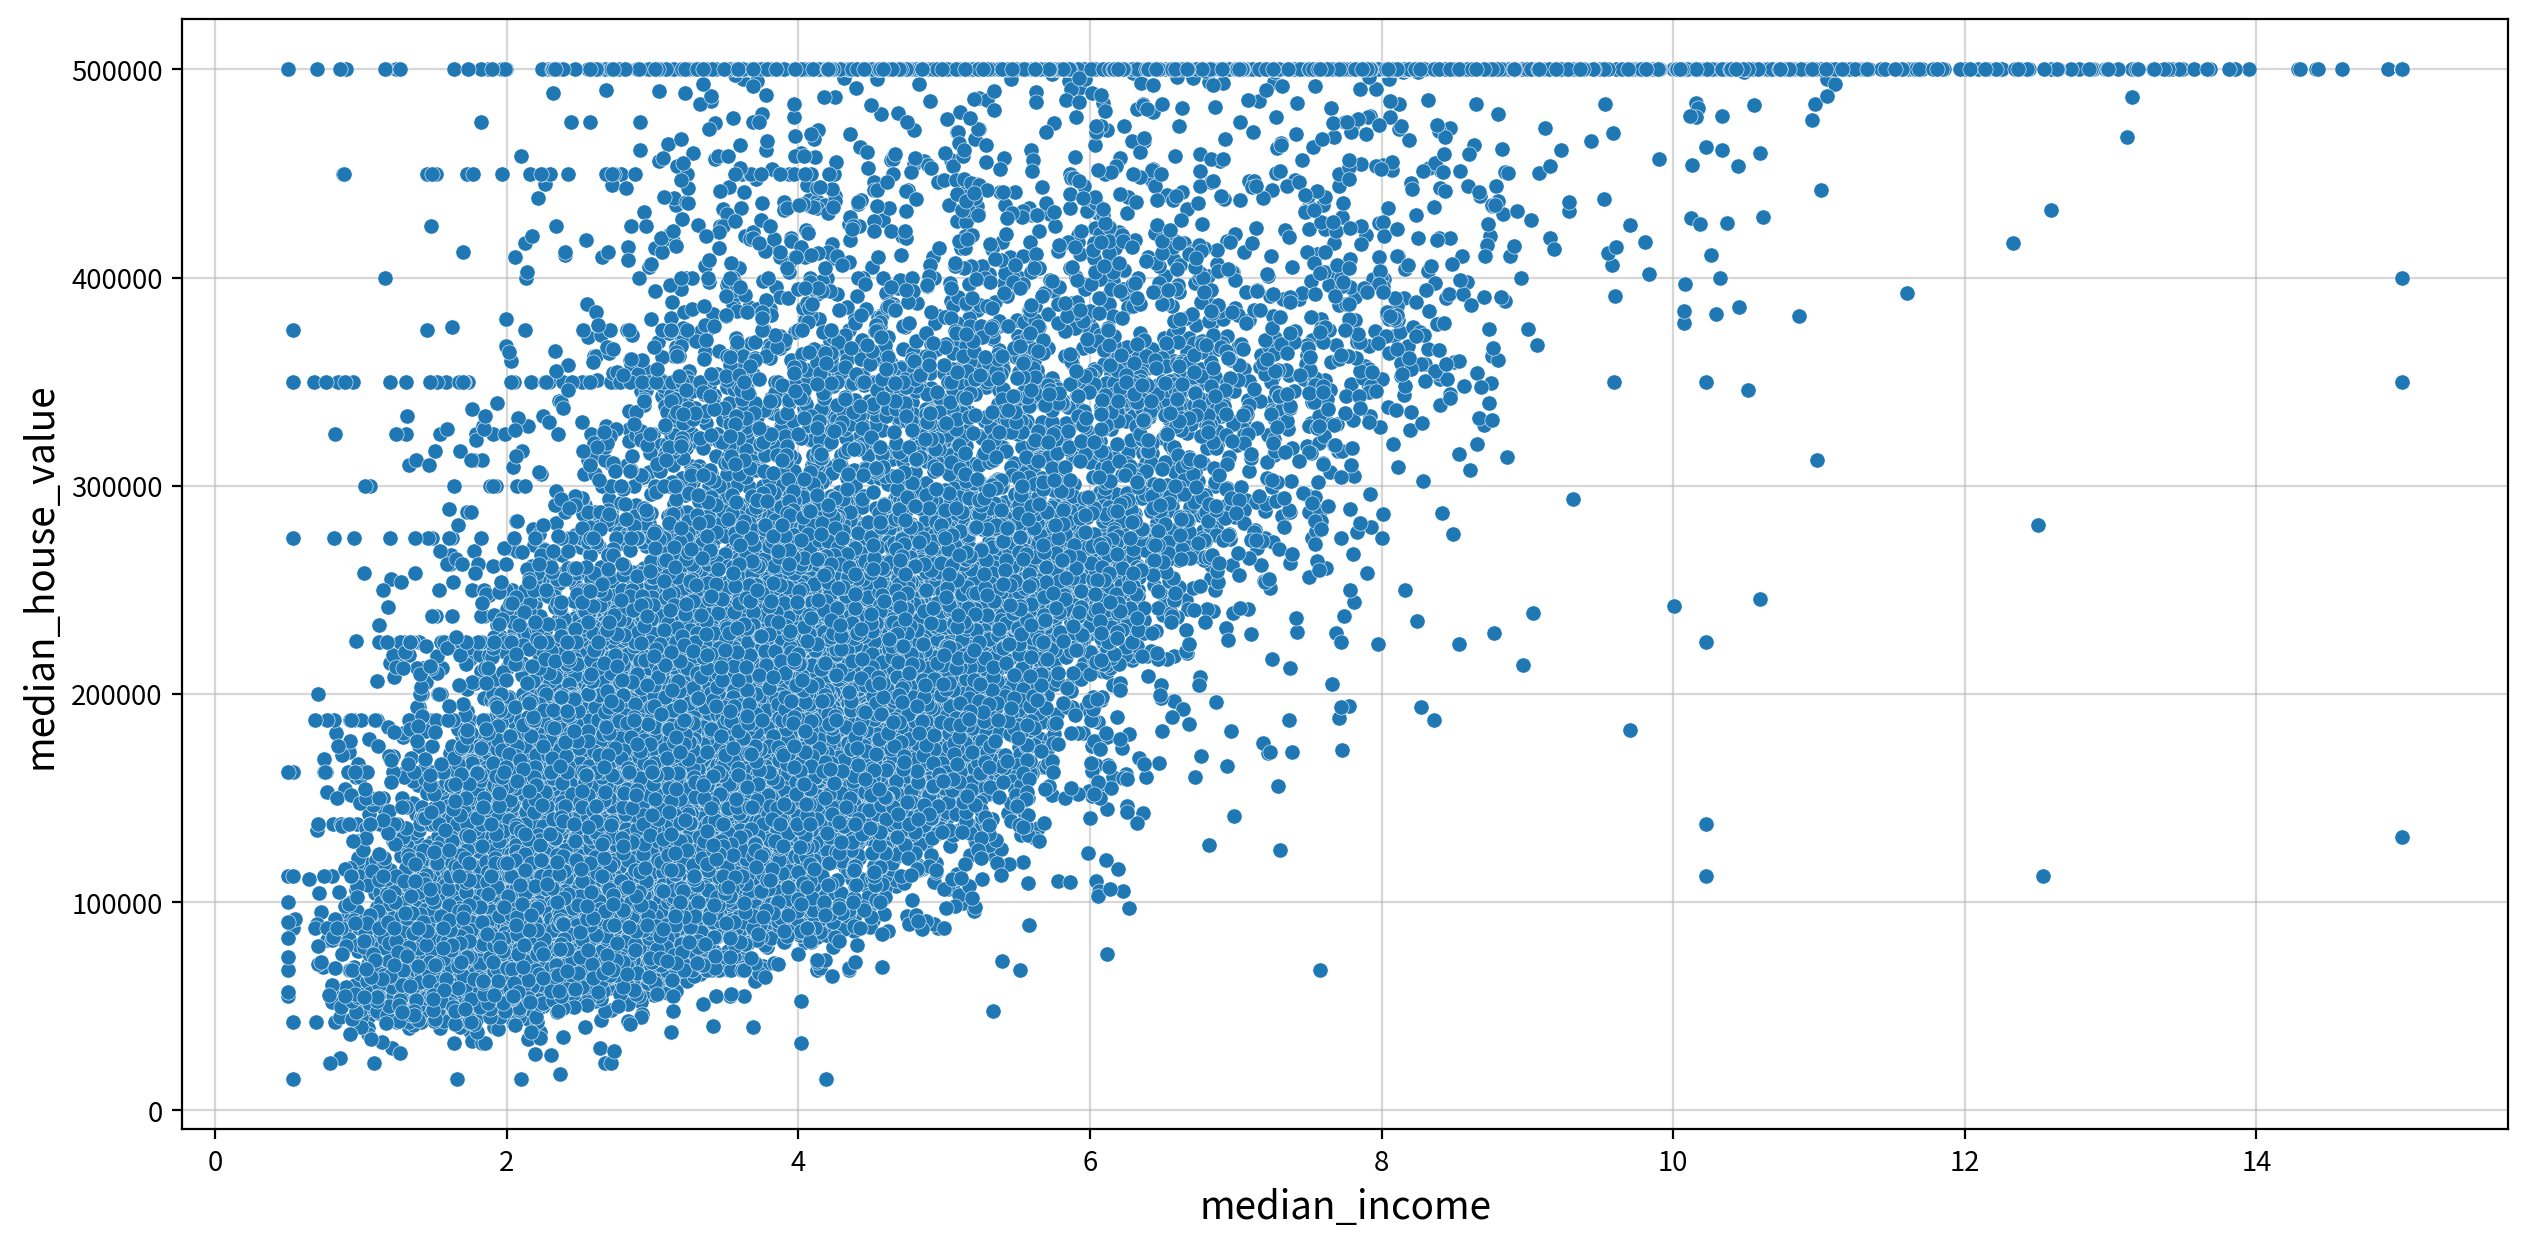

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
median_income,median_house_value,Spearman,0.677,0.000,Moderate,True,False,False,False,False,True


In [11]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth=0.2, size=30)
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

#### 인사이트

| 변수 | method | coef | strength | p-value | significant | normality | linearity | influential_outlier | high_skew |
|---|---|---|---|---|---|---|---|---|---|
| `median_income` | Spearman | **0.677** | **Moderate** | 0.000 | True | False | False | False | True |
| `total_rooms` | Spearman | 0.205 | Weak | 0.000 | True | False | False | False | True |
| `households` | Spearman | 0.112 | Weak | 0.000 | True | False | False | False | True |
| `total_bedrooms` | Spearman | 0.086 | Weak | 0.000 | True | False | False | False | True |
| `housing_median_age` | Spearman | 0.075 | Weak | 0.000 | True | False | False | False | **False** |
| `population` | Spearman | 0.003 | Weak | **0.681** | **False** | False | **True** | False | True |

##### 결과표에서 읽은 것

- **`strength`가 Weak이 아닌 변수는 `median_income` 하나뿐이다.** 유일한 Moderate이며, `coef`=0.677은 2위 `total_rooms`(0.205)의 3배가 넘는다. 나머지 5종은 0.003~0.205 구간에 모여 전부 Weak으로 라벨된다.
  → 근거: `strength`·`coef` 열
- **`significant`=False인 변수는 `population` 하나뿐이다.** `p-value`=0.681로, 나머지 5종이 모두 0.000인 것과 대비된다. `coef`도 0.003으로 6종 중 최저다.
  → 근거: `significant`·`p-value`·`coef` 열
- **`linearity`=True인 변수도 `population` 하나뿐이다.** 나머지 5종은 모두 False다. 유의하지 않은 변수에서만 선형성이 충족으로 나온 조합이므로, 이 True를 관계의 근거로 쓰지 않는다.
  → 근거: `linearity` 열
- **`influential_outlier`는 6종 모두 False다.** 단변량 분석의 `num_desc`에서 총량 변수마다 IQR 이상치가 5.8~6.3% 존재했으나, 그 행들을 제외해도 Pearson r 변화량이 0.1 미만이라는 뜻이다(판정 기준은 `helpers/my_stats.py`).
  → 근거: `influential_outlier` 열 + `num_desc`의 `outliers_ratio`
- **`high_skew`=False인 변수는 `housing_median_age` 하나뿐이다.** `num_desc`의 왜도(`housing_median_age` +0.062 / `total_rooms` +4.159 / `total_bedrooms` +3.460 / `population` +4.960 / `households` +3.414 / `median_income` +1.645)와 |왜도|>1 기준이 일치한다. 이 변수에서 Spearman이 채택된 사유는 왜도가 아니라 정규성 미충족이다.
  → 근거: `high_skew` 열 + `num_desc`의 `skew` 열

##### 산점도에서 읽은 것

- **상단 500,001$ 선의 수평 점열이 모든 산점도에서 공통 관찰됨**
  - 절단된 데이터임을 확인
- **`median_income` : 좌하→우상 방향의 추세** 
  - 점 구름의 하단 경계가 x가 커질수록 함께 올라가고, 세로 폭도 함께 넓어진다. 나머지 5종에는 이런 방향성이 없다.
- **총량 변수 3종(`total_rooms`·`total_bedrooms`·`households`)과 `population`은 좌측에 밀집하고 우측 긴 꼬리**
- **`housing_median_age`는 세로 줄무늬로 나타난다.**
  - x가 정수 눈금에만 값을 갖기 때문이며, 각 줄의 y 분포 범위가 x 전 구간에서 비슷

### 2. T-Test (x: 2집단 범주형 독립변수 → y: 종속변수)

In [12]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 인사이트

> 이 데이터셋에는 해당 없음


### 3. ANOVA (x: 3집단 범주형 독립변수 → y: 종속변수)

In [13]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))
        
        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ ocean_proximity(해양 근접도) → median_house_value

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_stats.py:91: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,ocean_proximity,4,31.918,2055.803,0.000,0.238,Large


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_stats.py:91: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


비교한 조합 쌍: 10개
유의한 쌍: 7개
평균 차이가 가장 큰 쌍: (INLAND) vs (ISLAND) -> 차이 255543.137, 효과크기 Large, p-value 0.010
평균 차이가 가장 작은 쌍: (INLAND) vs (ISLAND)-> 차이 255543.137, 효과크기 Large, p-value 0.010


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,<1H OCEAN,INLAND,240267.991,124896.863,115371.128,1415.614,81.499,15420.197,0.000,1.243,True,Large
1,Games-Howell,<1H OCEAN,ISLAND,240267.991,380440.000,-140172.009,36044.653,-3.889,4.008,0.076,-1.320,False,Large
2,Games-Howell,<1H OCEAN,NEAR BAY,240267.991,259279.292,-19011.301,2810.217,-6.765,3172.951,0.000,-0.173,True,Negligible
3,Games-Howell,<1H OCEAN,NEAR OCEAN,240267.991,249042.355,-8774.364,2638.754,-3.325,3846.759,0.008,-0.080,True,Negligible
4,Games-Howell,INLAND,ISLAND,124896.863,380440.000,-255543.137,36037.816,-7.091,4.005,0.010,-3.647,True,Large
5,Games-Howell,INLAND,NEAR BAY,124896.863,259279.292,-134382.429,2721.117,-49.385,2801.345,0.000,-1.547,True,Large
6,Games-Howell,INLAND,NEAR OCEAN,124896.863,249042.355,-124145.492,2543.654,-48.806,3343.938,0.000,-1.404,True,Large
7,Games-Howell,ISLAND,NEAR BAY,380440.000,259279.292,121160.708,36119.489,3.354,4.041,0.118,0.986,False,Large
8,Games-Howell,ISLAND,NEAR OCEAN,380440.000,249042.355,131397.645,36106.554,3.639,4.035,0.093,1.072,False,Large
9,Games-Howell,NEAR BAY,NEAR OCEAN,259279.292,249042.355,10236.937,3516.182,2.911,4789.540,0.030,0.083,True,Negligible


#### 인사이트

| 변수 | 집단 차이 | 효과크기 | 사후검정 구분력 | 채택 여부 |
|---|---|---|---|---|
| `ocean_proximity` | 유의 (Welch F=2,055.8, p<0.001) | np2=0.238 (Large) | 10쌍 중 7쌍 유의. `INLAND`를 뚜렷하게 분리 | 채택 (최우선) |

- 이 데이터셋에서 가장 강한 설명변수다. 효과크기 np2=0.238(Large)로, 연속형 최강인 `median_income`(ρ=0.677)에 필적하거나 그 이상이다.
- 집단 평균은 `INLAND` 124,897\$, `<1H OCEAN` 240,268\$, `NEAR OCEAN` 249,042\$, `NEAR BAY` 259,279\$, `ISLAND` 380,440\$ 순이다.
- 실질 구조는 5집단이 아니라 내륙과 해안권의 2집단이다.
  - `INLAND`와 나머지의 차이는 모두 효과크기 Large(hedges 1.24~1.55)다.
  - 반면 해안권 3종(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)끼리는 통계적으로 유의해도 효과크기가 모두 Negligible(hedges 0.08~0.17)이다. n이 커서 유의만 뜬 것이며 실질 차이는 없다.
  - 모델링 시 해안권 3종을 하나로 병합하는 것을 검토할 만하다.
- `ISLAND`(n=5)는 판정할 수 없다. 평균은 380,440\$로 가장 높지만, 관련된 4쌍 중 `INLAND`와의 비교(p=0.010) 하나만 유의하고 나머지 3쌍은 평균 차이가 12만~14만\$나 되는데도 비유의(p=0.076~0.118)다. 차이가 없어서가 아니라 표본 5개로는 검정력이 없기 때문이므로 해석에 사용하지 않는다.


## #04. 다변량 분석

### 1. 독립변수간 상관 분석

In [14]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
housing_median_age,1.000,-0.356,-0.306,-0.283,-0.281,-0.146
total_rooms,-0.356,1.000,0.915,0.816,0.906,0.271
total_bedrooms,-0.306,0.915,1.000,0.871,0.976,-0.006
population,-0.283,0.816,0.871,1.000,0.904,0.005
households,-0.281,0.906,0.976,0.904,1.000,0.029
median_income,-0.146,0.271,-0.006,0.005,0.029,1.000


,max-y,max-coef,count,columns
x,,,,
households,total_bedrooms,0.976,3,"total_bedrooms, total_rooms, population"
total_bedrooms,households,0.976,3,"households, total_rooms, population"
total_rooms,total_bedrooms,0.915,3,"total_bedrooms, households, population"
population,households,0.904,3,"households, total_bedrooms, total_rooms"
housing_median_age,total_rooms,-0.356,0,-
median_income,total_rooms,0.271,0,-


#### 인사이트

- 서로 상관인 변수: `total_rooms`, `total_bedrooms`, `population`, `households` 4종이 하나의 덩어리를 이룬다.
  - `households` ↔ `total_bedrooms` 0.976 (최대)
  - `total_rooms` ↔ `total_bedrooms` 0.915
  - `population` ↔ `households` 0.904
- 중복이 없는 변수: `median_income`(최대 0.271), `housing_median_age`(최대 -0.356)는 다른 변수와 겹치지 않는 독립적인 정보를 가진다.

## #05. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `ocean_proximity` | Welch ANOVA | $< 0.05$ | np2=0.238 (Large) | 해당 없음 | X | 단독 설명력 최상위. `INLAND`와 해안권의 격차가 11만\$ 이상(hedges 1.24~1.55)이므로 1순위 |
| 채택 | `median_income` | Spearman | $< 0.05$ | ρ=+0.677 (Moderate) | 우편향(+1.65) / log 변환 고려 | X (최대 0.271) | 연속형 중 유일한 실질 설명변수이고 중복도 없으므로 2순위 |
| 후보 | `total_rooms` | Spearman | $< 0.05$ | ρ=+0.205 (약함) | 강한 우편향(+4.16) / log 변환 고려 | O (total_bedrooms 0.915 / households 0.919) | 규모 축 4종 중 설명력 최상이므로 규모 축 대표로 후보 유지 |
| 후보 | `housing_median_age` | Spearman | $< 0.05$ | ρ=+0.075 (약함) | 대칭 / 변환 불필요 | X (최대 -0.356) | 설명력은 미미하나 중복이 없어 정보 가치가 있다. 계수 유의성으로 최종 판정 |
| 후보 | `households` | Spearman | $< 0.05$ | ρ=+0.112 (약함) | 강한 우편향(+3.41) / log 변환 고려 | O (total_bedrooms 0.976) | 설명력·중복 모두 열위라 규모 축 대표를 `total_rooms`에 양보. VIF 결과에 따라 대체 투입 |
| 후보 | `total_bedrooms` | Spearman | $< 0.05$ | ρ=+0.086 (약함) | 강한 우편향(+3.46) / log 변환 고려 | O (households 0.976) | 설명력·중복 모두 열위. 대표 양보 |
| 제외 | `population` | Spearman | 0.681 | ρ=+0.003 | 강한 우편향(+4.96) | O (households 0.904) | 유일한 비유의 변수. n=20,433 대표본에서도 p>0.05, ρ≈0으로 관계 자체가 없고 공선성까지 겹쳐 후보에서도 제외 |
| 별도 | `longitude`·`latitude` | - | - | - | 해당 없음 | - | 좌표 변수이므로 표준 연속형 트랙에서 제외. 공간 효과는 `ocean_proximity`가 대리하며, 파생변수화 후 재검토 (`#01-8` 참조) |

### 종합 판단

- 1순위 2종(`ocean_proximity`·`median_income`)이 설명력의 대부분을 차지한다. 위치와 소득이 집값을 결정한다는 도메인 상식과 일치한다.
- 나머지 총량 변수 4종은 개별 설명력이 약하고(ρ<0.21) 서로 심하게 중복(ρ≥0.90)된다. 그대로 넣기보다 비율형 파생변수(가구당 방 수, 방당 침실 비율, 가구당 인구)로 재구성한 뒤 재평가하는 것이 낫다.
- **전처리 선행 과제**
  1. 종속변수의 500,001\$ 절단 구간(958건) 플래그 관리
  2. `ocean_proximity`은 해안권(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)과 비해안권(`INLAND`)으로 다시 분류하고 `ISLAND`는 해안권에 흡수시킴
  3. `housing_median_age` 52년 절단(1,265건) 인지
  4. 종속변수 및 우편향 연속형 (`median_income`·`total_rooms`·`total_bedrooms`·`population`·`households`) log 변환
  5. 위·경도에 의한 공간 특성 반영